In [1]:
import os
import glob
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import xarray as xr
from matplotlib.colors import BoundaryNorm
import matplotlib.gridspec as gridspec
import pandas as pd
import datetime
import copy
from scipy.stats import linregress
import colorcet as cc
from sklearn.neighbors import KernelDensity
from scipy.ndimage import label, binary_dilation, generate_binary_structure, filters, iterate_structure
import warnings

import seaborn as sns
import scipy.stats as st
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import pingouin as pg

In [2]:
xr.__version__

'2023.5.0'

In [3]:
def list_dirs(in_dir):
    """
    List sub-directories.
    """
    dirs = []
    for it in os.scandir(in_dir):
        if it.is_dir():
            dirs.append(it.path)
    return dirs

def find_lasso_files(start_dates, root_datadir, in_basename, domain):
    files = []
    # Loop over dates
    for ii in range(0, len(start_dates)):
        # Get sub-directories (cases)
        idate = start_dates[ii]
        case_dirs = list_dirs(f'{root_datadir}/{idate}/')
        if len(case_dirs) > 0:
            # Loop over cases
            for icase in case_dirs:
                # Find config sub-directories
                # config_dirs = list_dirs(icase)
                config_dirs = [f'{icase}/base/']
                if len(config_dirs) > 0:
                    # Loop over configs
                    for iconfig in config_dirs:
                        # Find track stats file
                        fname = sorted(glob.glob(f'{iconfig}/{domain}/stats/{in_basename}*nc'))
                        if len(fname) > 0:
                            files.append(fname[0])
    return files

In [4]:
# LASSO case dates
start_dates = [
    "20181129", 
    "20181204",
    "20181205", 
    "20181219", 
    "20190122", 
    "20190123",
    "20190125",
    "20190129",
    "20190208",
]

# LASSO tracking directory
# rootdir_les = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/'
# rootdir_meso = '/gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/'
rootdir_les = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/'
rootdir_meso = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso/'
in_basename = 'trackstats_20'
in_basename_w = 'stats_3d_w_'
in_basename_env = 'stats_1d_env_'

figdir = '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/'

# Domain 4 boundaries
# lon_range = [-65., -63.1]
lon_range = [-65., -63.3]
lat_range = [-33., -30.8]
lifetime_range = [15, 1000]

# Find LASSO files
files_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename, 'd2')
files_d3 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd3')
files_d4 = find_lasso_files(start_dates, rootdir_les, in_basename, 'd4')
wfiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_w, 'd2')
wfiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd3')
wfiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_w, 'd4')
efiles_d2 = find_lasso_files(start_dates, rootdir_meso, in_basename_env, 'd2')
efiles_d3 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd3')
efiles_d4 = find_lasso_files(start_dates, rootdir_les, in_basename_env, 'd4')

print(f'Number of stats files (D2): {len(files_d2)}')
print(f'Number of W files (D2): {len(wfiles_d2)}')
print(f'Number of ENV files (D2): {len(efiles_d2)}')

print(f'Number of stats files (D3): {len(files_d3)}')
print(f'Number of W files (D3): {len(wfiles_d3)}')
print(f'Number of ENV files (D3): {len(efiles_d3)}')

print(f'Number of stats files (D4): {len(files_d4)}')
print(f'Number of W files (D4): {len(wfiles_d4)}')
print(f'Number of ENV files (D4): {len(efiles_d4)}')

files_d2, files_d3, files_d4, wfiles_d2, wfiles_d3, wfiles_d4

Number of stats files (D2): 18
Number of W files (D2): 18
Number of ENV files (D2): 18
Number of stats files (D3): 18
Number of W files (D3): 18
Number of ENV files (D3): 18
Number of stats files (D4): 18
Number of W files (D4): 18
Number of ENV files (D4): 18


(['/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs03/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs18/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs00/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181129/gefs09/base//d2/stats/trackstats_20181129.1200_20181130.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs19/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181204/gefs18/base//d2/stats/trackstats_20181204.1200_20181205.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181205/gefs01/base//d2/stats/trackstats_20181205.1200_20181206.0000.nc',
  '/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/meso//20181219/eda09/base//d2/sta

## Read & combine data files

In [5]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D2)
dst_d2 = xr.open_mfdataset(files_d2, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d2 = dst_d2.sizes['tracks']
dst_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

# Read W data (LASSO D2)
dsw_d2 = xr.open_mfdataset(wfiles_d2, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d2['tracks'] = np.arange(0, ntracks_d2)

# Read ENV data (LASSO D2)
dse_d2 = xr.open_mfdataset(efiles_d2, concat_dim='tracks', combine='nested')
dse_d2['tracks'] = np.arange(0, ntracks_d2)
dse_d2 = dse_d2.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d2 = xr.combine_by_coords([dst_d2, dsw_d2, dse_d2], combine_attrs='drop_conflicts')
ntimes_d2 = ds_d2.sizes['times']
ds_d2

Number of tracks (D2): 6498


<xarray.Dataset>
Dimensions:                  (tracks: 6498, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 6494 6495 6496 6497
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(219, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(219,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/meso/201...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       2.5

In [6]:
# ds = xr.open_dataset(files_d2[0], engine='netcdf4')
# dse_d2.LCL_height_mu.sel(times=-3).plot.hist()

In [7]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D3)
dst_d3 = xr.open_mfdataset(files_d3, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d3 = dst_d3.sizes['tracks']
dst_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

# Read W data (LASSO D3)
dsw_d3 = xr.open_mfdataset(wfiles_d3, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d3['tracks'] = np.arange(0, ntracks_d3)

# Read ENV data (LASSO D3)
dse_d3 = xr.open_mfdataset(efiles_d3, concat_dim='tracks', combine='nested')
dse_d3['tracks'] = np.arange(0, ntracks_d3)
dse_d3 = dse_d3.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d3 = xr.combine_by_coords([dst_d3, dsw_d3, dse_d3], combine_attrs='drop_conflicts')
ntimes_d3 = ds_d3.sizes['times']
ds_d3

Number of tracks (D3): 11051


<xarray.Dataset>
Dimensions:                  (tracks: 11051, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 ... 11047 11048 11049 11050
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/189)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(369, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(369,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

In [8]:
# Suppress the RuntimeWarning and FutureWarning from Xarray
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Read track data (LASSO D4)
dst_d4 = xr.open_mfdataset(files_d4, concat_dim='tracks', combine='nested', engine='netcdf4')
# Renumber tracks to make it continuous
ntracks_d4 = dst_d4.sizes['tracks']
dst_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

# Read W data (LASSO D4)
dsw_d4 = xr.open_mfdataset(wfiles_d4, concat_dim='tracks', combine='nested')
# Renumber tracks to make it continuous
dsw_d4['tracks'] = np.arange(0, ntracks_d4)

# Read ENV data (LASSO D4)
dse_d4 = xr.open_mfdataset(efiles_d4, concat_dim='tracks', combine='nested')
dse_d4['tracks'] = np.arange(0, ntracks_d4)
dse_d4 = dse_d4.rename({'z': 'height'})

# Combine 2D and 3D datasets by coordinates
ds_d4 = xr.combine_by_coords([dst_d4, dsw_d4, dse_d4], combine_attrs='drop_conflicts')
ntimes_d4 = ds_d4.sizes['times']
ds_d4

Number of tracks (D4): 8824


<xarray.Dataset>
Dimensions:                  (tracks: 8824, times: 212, height: 101, z: 40,
                              core: 10)
Coordinates:
  * tracks                   (tracks) int64 0 1 2 3 4 ... 8820 8821 8822 8823
  * times                    (times) int64 -12 -11 -10 -9 -8 ... 196 197 198 199
  * height                   (height) float64 0.0 200.0 400.0 ... 1.98e+04 2e+04
  * z                        (z) float64 250.0 500.0 750.0 ... 2e+04 2.1e+04
  * core                     (core) int64 0 1 2 3 4 5 6 7 8 9
Data variables: (12/183)
    temperature              (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    qv                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    rh                       (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    pressure                 (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    u                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    v                        (tracks, times, height) float32 dask.array<chunksize=(295, 212, 101), meta=np.ndarray>
    ...                       ...
    start_split_tracknumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_timeindex    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    start_split_cloudnumber  (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_tracknumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_timeindex      (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
    end_merge_cloudnumber    (tracks) float64 dask.array<chunksize=(295,), meta=np.ndarray>
Attributes:
    title:                 Tracked cell W statistics
    source_trackfile:      /gpfs/wolf/atm131/proj-shared/zfeng/cacti/les/2018...
    startdate:             20181129.1200
    enddate:               20181130.0000
    timegap_hour:          0.5
    time_resolution_hour:  0.08333
    pixel_radius_km:       0.5

## Subset tracks

In [9]:
# Constents common for all Datasets
time_res = 5.0  # [min]
xtime = ds_d2.times * time_res
height = ds_d2.z / 1000.

In [10]:
# Get track min/max lat/lon
minlon_d2 = ds_d2['meanlon'].min(dim='times').load()
maxlon_d2 = ds_d2['meanlon'].max(dim='times').load()
minlat_d2 = ds_d2['meanlat'].min(dim='times').load()
maxlat_d2 = ds_d2['meanlat'].max(dim='times').load()
lifetime_d2 = (ds_d2['track_duration'] * time_res).load()
# Subset d2 tracks that are within D4 boundary
ds_d2 = ds_d2.where((minlon_d2 >= min(lon_range)) & (maxlon_d2 <= max(lon_range)) & \
                    (minlat_d2 >= min(lat_range)) & (maxlat_d2 <= max(lat_range)) & \
                    (lifetime_d2 >= min(lifetime_range) & (lifetime_d2 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d2 = ds_d2.sizes['tracks']
ds_d2['tracks'] = np.arange(0, ntracks_d2)
print(f'Number of tracks (D2): {ntracks_d2}')

Number of tracks (D2): 3567


In [11]:
# Get track min/max lat/lon
minlon_d3 = ds_d3['meanlon'].min(dim='times').load()
maxlon_d3 = ds_d3['meanlon'].max(dim='times').load()
minlat_d3 = ds_d3['meanlat'].min(dim='times').load()
maxlat_d3 = ds_d3['meanlat'].max(dim='times').load()
lifetime_d3 = (ds_d3['track_duration'] * time_res).load()
# Subset D3 tracks that are within D4 boundary
ds_d3 = ds_d3.where((minlon_d3 >= min(lon_range)) & (maxlon_d3 <= max(lon_range)) & \
                    (minlat_d3 >= min(lat_range)) & (maxlat_d3 <= max(lat_range)) & \
                    (lifetime_d3 >= min(lifetime_range) & (lifetime_d3 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d3 = ds_d3.sizes['tracks']
ds_d3['tracks'] = np.arange(0, ntracks_d3)
print(f'Number of tracks (D3): {ntracks_d3}')

Number of tracks (D3): 5932


In [12]:
# Get track min/max lat/lon
minlon_d4 = ds_d4['meanlon'].min(dim='times').load()
maxlon_d4 = ds_d4['meanlon'].max(dim='times').load()
minlat_d4 = ds_d4['meanlat'].min(dim='times').load()
maxlat_d4 = ds_d4['meanlat'].max(dim='times').load()
lifetime_d4 = (ds_d4['track_duration'] * time_res).load()
# Subset d4 tracks that are within D4 boundary
ds_d4 = ds_d4.where((minlon_d4 >= min(lon_range)) & (maxlon_d4 <= max(lon_range)) & \
                    (minlat_d4 >= min(lat_range)) & (maxlat_d4 <= max(lat_range)) & \
                    (lifetime_d4 >= min(lifetime_range) & (lifetime_d4 <= max(lifetime_range))), drop=True)
# Renumber tracks to make it continuous
ntracks_d4 = ds_d4.sizes['tracks']
ds_d4['tracks'] = np.arange(0, ntracks_d4)
print(f'Number of tracks (D4): {ntracks_d4}')

Number of tracks (D4): 5336


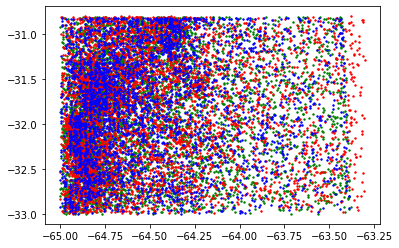

In [13]:
plt.scatter(ds_d3['meanlon'].mean(dim='times'), ds_d3['meanlat'].mean(dim='times'), s=2, c='g')
plt.scatter(ds_d4['meanlon'].mean(dim='times'), ds_d4['meanlat'].mean(dim='times'), s=2, c='r')
plt.scatter(ds_d2['meanlon'].mean(dim='times'), ds_d2['meanlat'].mean(dim='times'), s=2, c='b')

In [14]:
minlon_d4 = ds_d4['meanlon'].min().values
maxlon_d4 = ds_d4['meanlon'].max().values
minlat_d4 = ds_d4['meanlat'].min().values
maxlat_d4 = ds_d4['meanlat'].max().values
print(minlon_d4, maxlon_d4, minlat_d4, maxlat_d4)
print(lon_range, lat_range)

-64.99961 -63.304028 -32.998272 -30.800056
[-65.0, -63.3] [-33.0, -30.8]


In [15]:
# pts = [0.5, 0.75, 0.9, 0.95, 0.99]
# nCoreUp_pts_d2 = ds_d2.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d2.plot.line(y='z')

In [16]:
# nCoreUp_pts_d3 = ds_d3.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d3.plot.line(y='z')

In [17]:
# nCoreUp_pts_d4 = ds_d4.nCore_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times'), skipna=True, keep_attrs=True)
# nCoreUp_pts_d4.plot.line(y='z')

In [18]:
# CoreArea_pts_d2 = ds_d2.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d2 = np.sqrt(CoreArea_pts_d2 / np.pi)
# CoreRadius_pts_d2.plot.line(y='z')

In [19]:
# CoreArea_pts_d3 = ds_d3.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d3 = np.sqrt(CoreArea_pts_d3 / np.pi)
# CoreRadius_pts_d3.plot.line(y='z')

In [20]:
# CoreArea_pts_d4 = ds_d4.CoreArea_up.chunk(dict(tracks=-1)).quantile(pts, dim=('tracks','times','core'), skipna=True, keep_attrs=True)
# # Convert area to equivalent radius
# CoreRadius_pts_d4 = np.sqrt(CoreArea_pts_d4 / np.pi)
# CoreRadius_pts_d4.plot.line(y='z')

## Find merge/split track indices

In [21]:
def find_merge_split_tracks(ds):
    """
    Find merge/split track indices.
    """
    # non-split tracks
    idx_nsplit = np.isnan(ds.start_split_cloudnumber.load())
    # non-merge tracks
    idx_nmerge = np.isnan(ds.end_merge_cloudnumber.load())
    # non-merge and non-split tracks
    idx_nms = np.isnan(ds.start_split_cloudnumber.load()) & np.isnan(ds.end_merge_cloudnumber.load())
    # merge or split tracks
    idx_ms = ~np.isnan(ds.start_split_cloudnumber.load()) | ~np.isnan(ds.end_merge_cloudnumber.load())
    # Group outputs to dictionary
    out_dict = {
        'ms': idx_ms,
        'nms': idx_nms,
        'nm': idx_nmerge,
        'ns': idx_nsplit,
    }
    return out_dict

In [22]:
tid_d2 = find_merge_split_tracks(ds_d2)
tid_d3 = find_merge_split_tracks(ds_d3)
tid_d4 = find_merge_split_tracks(ds_d4)

In [23]:
# ntracks_nms_d2 = np.count_nonzero(tid_d2['nms'] == True)
# ntracks_ns_d2 = np.count_nonzero(tid_d2['ns'] == True)
# print(f'D2 non-merge-split tracks: {ntracks_nms_d2}, non-split tracks: {ntracks_ns_d2}')

In [24]:
# ntracks_nms_d3 = np.count_nonzero(tid_d3['nms'] == True)
# ntracks_ns_d3 = np.count_nonzero(tid_d3['ns'] == True)
# print(f'D3 non-merge-split tracks: {ntracks_nms_d3}, non-split tracks: {ntracks_ns_d3}')

In [25]:
# ntracks_nms_d4 = np.count_nonzero(tid_d4['nms'] == True)
# ntracks_ns_d4 = np.count_nonzero(tid_d4['ns'] == True)
# print(f'D4 non-merge-split tracks: {ntracks_nms_d4}, non-split tracks: {ntracks_ns_d4}')

## Subset DataSets with non-merge/non-split tracks

In [26]:
dsnms_d2 = ds_d2.isel(tracks=tid_d2['nms'])
dsnms_d3 = ds_d3.isel(tracks=tid_d3['nms'])
dsnms_d4 = ds_d4.isel(tracks=tid_d4['nms'])

# Get number of tracks
ntracks_nms_d2 = dsnms_d2.sizes['tracks']
ntracks_nms_d3 = dsnms_d3.sizes['tracks']
ntracks_nms_d4 = dsnms_d4.sizes['tracks']
print(f'D2 non-merge-split tracks: {ntracks_nms_d2}')
print(f'D3 non-merge-split tracks: {ntracks_nms_d3}')
print(f'D4 non-merge-split tracks: {ntracks_nms_d4}')

D2 non-merge-split tracks: 1271
D3 non-merge-split tracks: 2553
D4 non-merge-split tracks: 2697


## Subset DataSets with non-split tracks

In [27]:
# dsns_d2 = ds_d2.isel(tracks=tid_d2['ns'])
# dsns_d3 = ds_d3.isel(tracks=tid_d3['ns'])
# dsns_d4 = ds_d4.isel(tracks=tid_d4['ns'])

# ntracks_ns_d2 = dsns_d2.sizes['tracks']
# ntracks_ns_d3 = dsns_d3.sizes['tracks']
# ntracks_ns_d4 = dsns_d4.sizes['tracks']
# print(f'D2 non-split tracks: {ntracks_ns_d2}')
# print(f'D3 non-split tracks: {ntracks_ns_d3}')
# print(f'D4 non-split tracks: {ntracks_ns_d4}')

In [28]:
# Get some constents common for all Datasets
ntimes = dsnms_d2.dims['times']
nz = dsnms_d2.dims['z']
ncores = dsnms_d2.dims['core']

# time_res = 5.0  # [min]
# xtime = dsnms_d2.times * time_res
# height = dsnms_d2.z / 1000.

In [29]:
# Get cell track lifetime: track_duration x time_resolution [min]
track_lifetime_d2 = dsnms_d2['track_duration'].load() * time_res
track_lifetime_d3 = dsnms_d3['track_duration'].load() * time_res
track_lifetime_d4 = dsnms_d4['track_duration'].load() * time_res

# Cell max reflectivity
maxdbz_d2 = dsnms_d2['max_dbz'].load()
maxdbz_d3 = dsnms_d3['max_dbz'].load()
maxdbz_d4 = dsnms_d4['max_dbz'].load()
# Cell ETH
maxETH_10dbz_d2 = dsnms_d2['maxETH_10dbz'].load()
maxETH_10dbz_d3 = dsnms_d3['maxETH_10dbz'].load()
maxETH_10dbz_d4 = dsnms_d4['maxETH_10dbz'].load()
# Cell diameter
cellarea_d2 = dsnms_d2['cell_area'].load()
cellarea_d3 = dsnms_d3['cell_area'].load()
cellarea_d4 = dsnms_d4['cell_area'].load()
celldiam_d2 = 2 * np.sqrt(cellarea_d2 / np.pi)
celldiam_d3 = 2 * np.sqrt(cellarea_d3 / np.pi)
celldiam_d4 = 2 * np.sqrt(cellarea_d4 / np.pi)

In [30]:
# # Get preCI environmental variables
# ntimes_preCI = 12
# # Convert MU EL(LNB) height to [km]
# MULNB_d2 = dsnms_d2.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d3 = dsnms_d3.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000
# MULNB_d4 = dsnms_d4.EL_height_mu.sel(times=slice(-1*ntimes_preCI,0))/1000

# MUCAPE_d2 = dsnms_d2.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d3 = dsnms_d3.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))
# MUCAPE_d4 = dsnms_d4.CAPE_mu.sel(times=slice(-1*ntimes_preCI,0))

In [31]:
# dsnms_d2.Z_surface.isel(tracks=200).plot()

(array([284., 459., 381., 376., 306., 250., 213., 169., 212.,  39.]),
 array([ 117.80387,  364.77737,  611.75085,  858.72437, 1105.6979 ,
        1352.6714 , 1599.6449 , 1846.6183 , 2093.5918 , 2340.5654 ,
        2587.5388 ], dtype=float32),
 <BarContainer object of 10 artists>)

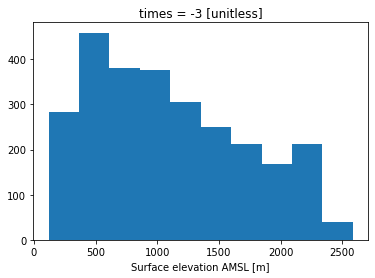

In [32]:
dsnms_d4.Z_surface.sel(times=-3).plot.hist()

In [33]:
# Get preCI MU LNB
preCI_time = -3  # preCI time
# Select preCI time, the drop the times coordinate (this avoids conflict with cell lifetime-max variables that has no times coordinate)
# Add surface elevation to convert LNB from HAMSL to HAGL
# MULNB_d2 = ((dsnms_d2.EL_height_mu + dsnms_d2.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d3 = ((dsnms_d3.EL_height_mu + dsnms_d3.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
# MULNB_d4 = ((dsnms_d4.EL_height_mu + dsnms_d4.Z_surface).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d2 = ((dsnms_d2.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d3 = ((dsnms_d3.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)
MULNB_d4 = ((dsnms_d4.EL_height_mu).sel(times=preCI_time)/1000).reset_coords('times', drop=True)

(array([0.00075047, 0.        , 0.00150094, 0.00225141, 0.00075047,
        0.00075047, 0.00600375, 0.0097561 , 0.01050657, 0.00525328,
        0.0097561 , 0.00825516, 0.00600375, 0.01801126, 0.06904315,
        0.12082552, 0.15984991, 0.19362101, 0.15609756, 0.06529081,
        0.01651032, 0.03527205, 0.06003752, 0.06829268, 0.11707317,
        0.16360225, 0.1380863 , 0.15984991, 0.14409006, 0.11707317,
        0.08780488, 0.04427767, 0.00375235, 0.        , 0.        ,
        0.        ]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5, 17. , 17.5, 18. ]),
 <BarContainer object of 36 artists>)

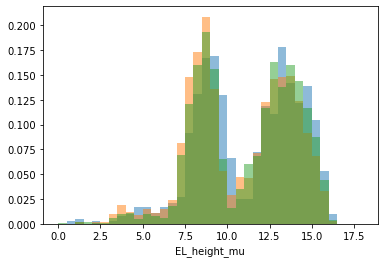

In [34]:
bins = np.arange(0, 18.1, 0.5)
MULNB_d2.plot.hist(bins=bins, alpha=0.5, label='D2', density=True)
MULNB_d3.plot.hist(bins=bins, alpha=0.5, label='D3', density=True)
MULNB_d4.plot.hist(bins=bins, alpha=0.5, label='D4', density=True)

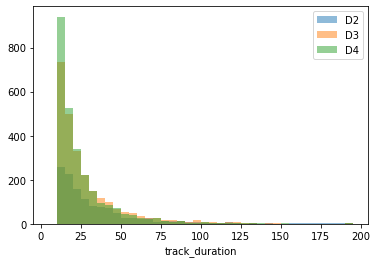

In [35]:
bins = np.arange(5,200,5)
track_lifetime_d2.plot.hist(bins=bins, alpha=0.5, label='D2')
track_lifetime_d3.plot.hist(bins=bins, alpha=0.5, label='D3')
track_lifetime_d4.plot.hist(bins=bins, alpha=0.5, label='D4')
plt.legend()

In [36]:
np.count_nonzero(track_lifetime_d4 == 10)

940

In [37]:
# bins = np.arange(0, 6000.1, 200)
# MUCAPE_d2.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D2')
# MUCAPE_d3.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D3')
# MUCAPE_d4.sel(times=-3).plot.hist(bins=bins, alpha=0.5, label='D4')

In [38]:
# bins = np.arange(2, 31, 2)
# celldiam_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
# celldiam_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
# celldiam_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')

In [39]:
# bins = np.arange(2,16,1)
# maxETH_10dbz_d2.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D2')
# maxETH_10dbz_d3.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D3')
# maxETH_10dbz_d4.max(dim='times').plot.hist(bins=bins, alpha=0.5, label='D4')
# plt.legend()

## Get lifetime-max 10dBZ ETH and cell diameter percentile values

In [40]:
ETH_percentiles = [0.33, 0.5, 0.66]
trackmaxETH_10dbz_d2 = maxETH_10dbz_d2.max(dim='times')
max10dbz_pts_d2 = trackmaxETH_10dbz_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D2): {max10dbz_pts_d2.values}")

trackmaxCellDiam_d2 = celldiam_d2.max(dim='times')
maxCellDiam_pts_d2 = trackmaxCellDiam_d2.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D2): {maxCellDiam_pts_d2.values}")

Max 10dBZ percentile values (D2): [4.   4.75 6.  ]
Max CellDiam percentile values (D2): [ 9.7720499  10.17107201 11.96826839]


In [41]:
trackmaxETH_10dbz_d3 = maxETH_10dbz_d3.max(dim='times')
max10dbz_pts_d3 = trackmaxETH_10dbz_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D3): {max10dbz_pts_d3.values}")

trackmaxCellDiam_d3 = celldiam_d3.max(dim='times')
maxCellDiam_pts_d3 = trackmaxCellDiam_d3.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D3): {maxCellDiam_pts_d3.values}")

Max 10dBZ percentile values (D3): [5.25 6.   7.  ]
Max CellDiam percentile values (D3): [4.95074368 5.58519173 6.635397  ]


In [42]:
trackmaxETH_10dbz_d4 = maxETH_10dbz_d4.max(dim='times')
max10dbz_pts_d4 = trackmaxETH_10dbz_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max 10dBZ percentile values (D4): {max10dbz_pts_d4.values}")

trackmaxCellDiam_d4 = celldiam_d4.max(dim='times')
maxCellDiam_pts_d4 = trackmaxCellDiam_d4.quantile(ETH_percentiles, keep_attrs=True, skipna=True)
print(f"Max CellDiam percentile values (D4): {maxCellDiam_pts_d4.values}")

Max 10dBZ percentile values (D4): [5.  5.5 6.5]
Max CellDiam percentile values (D4): [4.90810179 5.41151619 6.28254938]


## Plot cell diameter & ETH PDF with narrow & wide cell cutoffs

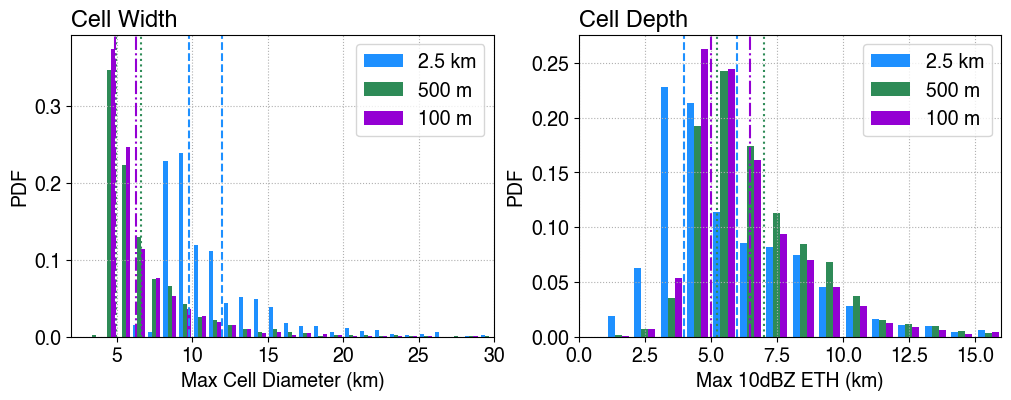

In [43]:
mpl.rcParams['font.size'] = 14
mpl.rcParams['font.family'] = 'Helvetica'

fig, axes = plt.subplots(1, 2, figsize=(12,4), dpi=100)
lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}

ax = axes[0]
bins = np.arange(2, 31, 1)
bar_data = [trackmaxCellDiam_d2, trackmaxCellDiam_d3, trackmaxCellDiam_d4]
bar_labels = list(name_map.values())
bar_colors = list(lcolors.values())
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
ax.legend()
# Percentile lines
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
ax.axvline(maxCellDiam_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.set_xlim((2,30))
ax.set_xlabel('Max Cell Diameter (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Width', loc='left')
ax.grid(ls=':')

ax = axes[1]
bins = np.arange(0, 17, 1)
bar_data = [trackmaxETH_10dbz_d2, trackmaxETH_10dbz_d3, trackmaxETH_10dbz_d4]
ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)

# Percentile lines
ax.axvline(max10dbz_pts_d2.sel(quantile=0.33), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d2.sel(quantile=0.66), ls='--', color=lcolors['d2'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.33), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d3.sel(quantile=0.66), ls=':', color=lcolors['d3'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.33), ls='dashdot', color=lcolors['d4'],)
ax.axvline(max10dbz_pts_d4.sel(quantile=0.66), ls='dashdot', color=lcolors['d4'],)
ax.legend()
ax.set_xlim((0,16))
ax.set_xlabel('Max 10dBZ ETH (km)')
ax.set_ylabel('PDF')
ax.set_title('Cell Depth', loc='left')
ax.grid(ls=':')

# figname = f'{figdir}PDF_maxCellDiam_maxETH10dBZ_d2_d3_d4.png'
# fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Separate narrow vs. wide cell DataSets

In [44]:
MULNB_d2.shape, trackmaxCellDiam_d2.shape

((1271,), (1271,))

In [45]:
# MU LNB threshold, cells must have LNB > this to be retained in the subsequent analysis
MULNB_thresh = 6.0  # [km]

# Quantiles for narrow & wide
narrow_qt = 0.33
wide_qt = 0.66

In [46]:
# Define narrow vs. wide thresholds
narrow_diam_d2 = maxCellDiam_pts_d2.sel(quantile=narrow_qt).item()
wide_diam_d2 = maxCellDiam_pts_d2.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D2): {narrow_diam_d2:.02f} km')
print(f'Wide diameter threshold (D2): {wide_diam_d2:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d2 = ((trackmaxCellDiam_d2 <= narrow_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
wide_tracks_d2 = ((trackmaxCellDiam_d2 >= wide_diam_d2) & (MULNB_d2 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d2 = dsnms_d2.where(narrow_tracks_d2, drop=True)
ds_wide_d2 = dsnms_d2.where(wide_tracks_d2, drop=True)
ntracks_narrow_d2 = ds_narrow_d2.sizes['tracks']
ntracks_wide_d2 = ds_wide_d2.sizes['tracks']
print(f'Number of narrow cells (D2): {ntracks_narrow_d2}')
print(f'Number of wide cells (D2): {ntracks_wide_d2}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d2 = ds_narrow_d2.track_duration * time_res
wide_track_lifetime_d2 = ds_wide_d2.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d2 = ds_narrow_d2.max_dbz.max(dim='times')
wide_maxdbz_d2 = ds_wide_d2.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d2 = ds_narrow_d2.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d2 = ds_wide_d2.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d2 = 2 * np.sqrt(ds_narrow_d2.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d2 = 2 * np.sqrt(ds_wide_d2.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D2): 9.77 km
Wide diameter threshold (D2): 11.97 km
Number of narrow cells (D2): 588
Number of wide cells (D2): 446


(array([ 0.,  0.,  7., 18., 50., 58., 54., 63., 61., 49., 27., 18., 14.,
        10.,  6.,  8.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 <BarContainer object of 16 artists>)

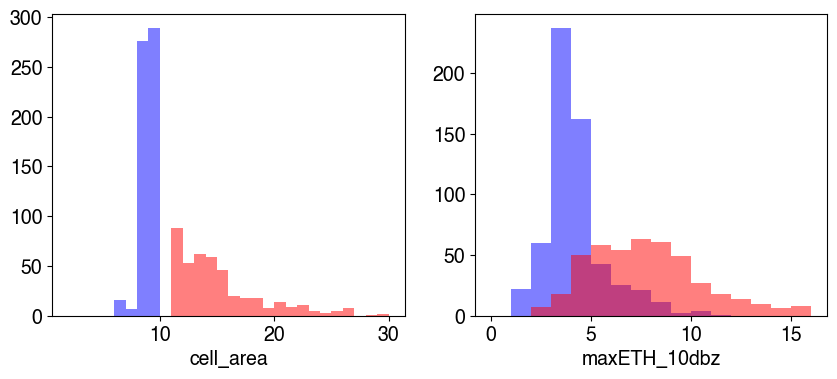

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=100)
ax1 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxdiam_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[1]
bins = np.arange(0, 17, 1)
narrow_maxETH10dbz_d2.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d2.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [48]:
# Define narrow vs. wide thresholds
narrow_diam_d3 = maxCellDiam_pts_d3.sel(quantile=narrow_qt).item()
wide_diam_d3 = maxCellDiam_pts_d3.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D3): {narrow_diam_d3:.02f} km')
print(f'Wide diameter threshold (D3): {wide_diam_d3:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d3 = ((trackmaxCellDiam_d3 <= narrow_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
wide_tracks_d3 = ((trackmaxCellDiam_d3 >= wide_diam_d3) & (MULNB_d3 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d3 = dsnms_d3.where(narrow_tracks_d3, drop=True)
ds_wide_d3 = dsnms_d3.where(wide_tracks_d3, drop=True)
ntracks_narrow_d3 = ds_narrow_d3.sizes['tracks']
ntracks_wide_d3 = ds_wide_d3.sizes['tracks']
print(f'Number of narrow cells (D3): {ntracks_narrow_d3}')
print(f'Number of wide cells (D3): {ntracks_wide_d3}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d3 = ds_narrow_d3.track_duration * time_res
wide_track_lifetime_d3 = ds_wide_d3.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d3 = ds_narrow_d3.max_dbz.max(dim='times')
wide_maxdbz_d3 = ds_wide_d3.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d3 = ds_narrow_d3.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d3 = ds_wide_d3.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d3 = 2 * np.sqrt(ds_narrow_d3.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d3 = 2 * np.sqrt(ds_wide_d3.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D3): 4.95 km
Wide diameter threshold (D3): 6.64 km
Number of narrow cells (D3): 824
Number of wide cells (D3): 823


(array([  0.,   0.,   2.,   1.,   3.,  42., 115., 158., 159., 144.,  85.,
         37.,  29.,  23.,  13.,   9.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 <BarContainer object of 16 artists>)

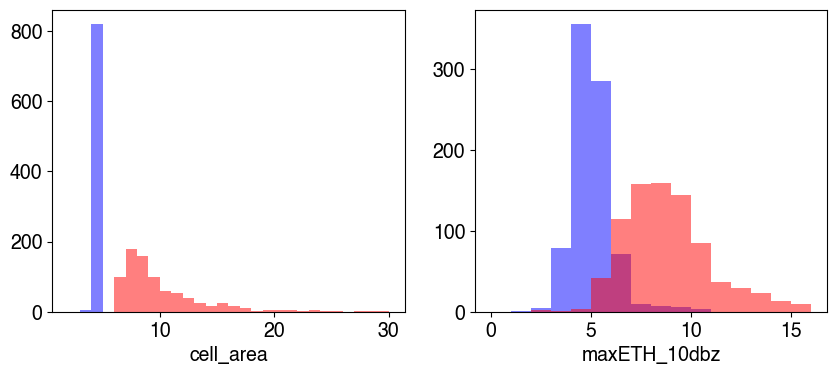

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=100)
ax1 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxdiam_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[1]
bins = np.arange(0, 17, 1)
narrow_maxETH10dbz_d3.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d3.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

In [50]:
# Define narrow vs. wide thresholds
narrow_diam_d4 = maxCellDiam_pts_d4.sel(quantile=narrow_qt).item()
wide_diam_d4 = maxCellDiam_pts_d4.sel(quantile=wide_qt).item()
print(f'Narrow diameter threshold (D4): {narrow_diam_d4:.02f} km')
print(f'Wide diameter threshold (D4): {wide_diam_d4:.02f} km')

# Separate narrow vs. wide cell DataSets, also require LNB > MULNB_thresh
narrow_tracks_d4 = ((trackmaxCellDiam_d4 <= narrow_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
wide_tracks_d4 = ((trackmaxCellDiam_d4 >= wide_diam_d4) & (MULNB_d4 > MULNB_thresh)).compute()
# Subset DataSets
ds_narrow_d4 = dsnms_d4.where(narrow_tracks_d4, drop=True)
ds_wide_d4 = dsnms_d4.where(wide_tracks_d4, drop=True)
ntracks_narrow_d4 = ds_narrow_d4.sizes['tracks']
ntracks_wide_d4 = ds_wide_d4.sizes['tracks']
print(f'Number of narrow cells (D4): {ntracks_narrow_d4}')
print(f'Number of wide cells (D4): {ntracks_wide_d4}')

# Get cell track lifetime: track_duration x time_resolution [min]
narrow_track_lifetime_d4 = ds_narrow_d4.track_duration * time_res
wide_track_lifetime_d4 = ds_wide_d4.track_duration * time_res
# Lifetime-max reflectivity
narrow_maxdbz_d4 = ds_narrow_d4.max_dbz.max(dim='times')
wide_maxdbz_d4 = ds_wide_d4.max_dbz.max(dim='times')
# Lifetime-max 10dBZ ETH
narrow_maxETH10dbz_d4 = ds_narrow_d4.maxETH_10dbz.max(dim='times')
wide_maxETH10dbz_d4 = ds_wide_d4.maxETH_10dbz.max(dim='times')
# Lifetime-max diameter
narrow_maxdiam_d4 = 2 * np.sqrt(ds_narrow_d4.cell_area.max(dim='times') / np.pi)
wide_maxdiam_d4 = 2 * np.sqrt(ds_wide_d4.cell_area.max(dim='times') / np.pi)

Narrow diameter threshold (D4): 4.91 km
Wide diameter threshold (D4): 6.28 km
Number of narrow cells (D4): 866
Number of wide cells (D4): 875


(array([  0.,   0.,   1.,   1.,  20., 112., 174., 172., 137., 100.,  67.,
         31.,  23.,  15.,   6.,  11.]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 <BarContainer object of 16 artists>)

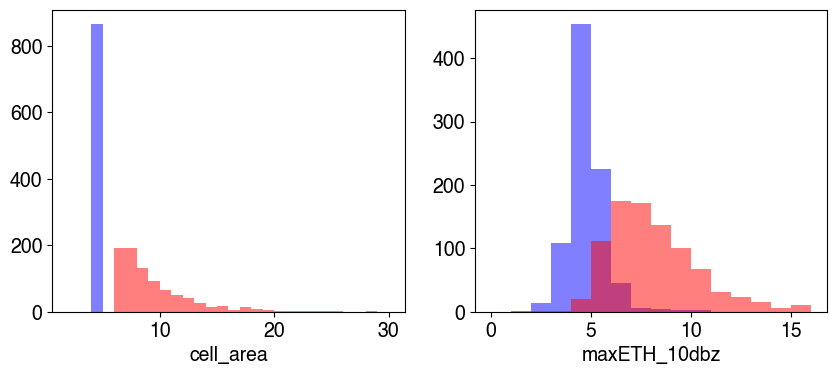

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10,4), dpi=100)
ax1 = axes[0]
bins = np.arange(2, 31, 1)
narrow_maxdiam_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax1)
wide_maxdiam_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax1)
ax2 = axes[1]
bins = np.arange(0, 17, 1)
narrow_maxETH10dbz_d4.plot.hist(bins=bins, color='blue', alpha=0.5, ax=ax2)
wide_maxETH10dbz_d4.plot.hist(bins=bins, color='red', alpha=0.5, ax=ax2)

## Get environmental parameters for narrow vs. wide cells

In [52]:
# ntimes_preCI = 13
preCI_t = -3  # preCI time to get a single value

# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d2 = ds_narrow_d2.pEL_height_mu.sel(times=preCI_t).load()/1000
narrow_pCAPEmu_d2 = ds_narrow_d2.pCAPE_mu.sel(times=preCI_t).load()
narrow_pCAPEacbl_d2 = ds_narrow_d2.pCAPEacbl_ml.sel(times=preCI_t).load()
narrow_pCINmu_d2 = ds_narrow_d2.pCIN_mu.sel(times=preCI_t).load()
narrow_LCLz_d2 = ds_narrow_d2.LCL_height_mu.sel(times=preCI_t).load()/1000
narrow_LCLt_d2 = ds_narrow_d2.LCL_temp_mu.sel(times=preCI_t).load()
narrow_pLFCz_d2 = ds_narrow_d2.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
narrow_RHacbl_d2 = ds_narrow_d2.RH_mean_ACBL.sel(times=preCI_t).load()
narrow_RH600mb_d2 = ds_narrow_d2.rh_600mb.sel(times=preCI_t).load()
narrow_RH500mb_d2 = ds_narrow_d2.rh_500mb.sel(times=preCI_t).load()
narrow_RHlfc1500_d2 = ds_narrow_d2.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
narrow_PW_d2 = ds_narrow_d2.PW.sel(times=preCI_t).load()
# Wind shear
narrow_BWSacbl_d2 = ds_narrow_d2.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
narrow_BWS03km_d2 = ds_narrow_d2.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
narrow_BWS06km_d2 = ds_narrow_d2.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d2 = ds_wide_d2.pEL_height_mu.sel(times=preCI_t).load()/1000
wide_pCAPEmu_d2 = ds_wide_d2.pCAPE_mu.sel(times=preCI_t).load()
wide_pCAPEacbl_d2 = ds_wide_d2.pCAPEacbl_ml.sel(times=preCI_t).load()
wide_pCINmu_d2 = ds_wide_d2.pCIN_mu.sel(times=preCI_t).load()
wide_LCLz_d2 = ds_wide_d2.LCL_height_mu.sel(times=preCI_t).load()/1000
wide_LCLt_d2 = ds_wide_d2.LCL_temp_mu.sel(times=preCI_t).load()
wide_pLFCz_d2 = ds_wide_d2.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
wide_RHacbl_d2 = ds_wide_d2.RH_mean_ACBL.sel(times=preCI_t).load()
wide_RH600mb_d2 = ds_wide_d2.rh_600mb.sel(times=preCI_t).load()
wide_RH500mb_d2 = ds_wide_d2.rh_500mb.sel(times=preCI_t).load()
wide_RHlfc1500_d2 = ds_wide_d2.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
wide_PW_d2 = ds_wide_d2.PW.sel(times=preCI_t).load()
# Wind shear
wide_BWSacbl_d2 = ds_wide_d2.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
wide_BWS03km_d2 = ds_wide_d2.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
wide_BWS06km_d2 = ds_wide_d2.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

In [53]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d3 = ds_narrow_d3.pEL_height_mu.sel(times=preCI_t).load()/1000
narrow_pCAPEmu_d3 = ds_narrow_d3.pCAPE_mu.sel(times=preCI_t).load()
narrow_pCAPEacbl_d3 = ds_narrow_d3.pCAPEacbl_ml.sel(times=preCI_t).load()
narrow_pCINmu_d3 = ds_narrow_d3.pCIN_mu.sel(times=preCI_t).load()
narrow_LCLz_d3 = ds_narrow_d3.LCL_height_mu.sel(times=preCI_t).load()/1000
narrow_LCLt_d3 = ds_narrow_d3.LCL_temp_mu.sel(times=preCI_t).load()
narrow_pLFCz_d3 = ds_narrow_d3.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
narrow_RHacbl_d3 = ds_narrow_d3.RH_mean_ACBL.sel(times=preCI_t).load()
narrow_RH600mb_d3 = ds_narrow_d3.rh_600mb.sel(times=preCI_t).load()
narrow_RH500mb_d3 = ds_narrow_d3.rh_500mb.sel(times=preCI_t).load()
narrow_RHlfc1500_d3 = ds_narrow_d3.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
narrow_PW_d3 = ds_narrow_d3.PW.sel(times=preCI_t).load()
# Wind shear
narrow_BWSacbl_d3 = ds_narrow_d3.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
narrow_BWS03km_d3 = ds_narrow_d3.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
narrow_BWS06km_d3 = ds_narrow_d3.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d3 = ds_wide_d3.pEL_height_mu.sel(times=preCI_t).load()/1000
wide_pCAPEmu_d3 = ds_wide_d3.pCAPE_mu.sel(times=preCI_t).load()
wide_pCAPEacbl_d3 = ds_wide_d3.pCAPEacbl_ml.sel(times=preCI_t).load()
wide_pCINmu_d3 = ds_wide_d3.pCIN_mu.sel(times=preCI_t).load()
wide_LCLz_d3 = ds_wide_d3.LCL_height_mu.sel(times=preCI_t).load()/1000
wide_LCLt_d3 = ds_wide_d3.LCL_temp_mu.sel(times=preCI_t).load()
wide_pLFCz_d3 = ds_wide_d3.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
wide_RHacbl_d3 = ds_wide_d3.RH_mean_ACBL.sel(times=preCI_t).load()
wide_RH600mb_d3 = ds_wide_d3.rh_600mb.sel(times=preCI_t).load()
wide_RH500mb_d3 = ds_wide_d3.rh_500mb.sel(times=preCI_t).load()
wide_RHlfc1500_d3 = ds_wide_d3.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
wide_PW_d3 = ds_wide_d3.PW.sel(times=preCI_t).load()
# Wind shear
wide_BWSacbl_d3 = ds_wide_d3.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
wide_BWS03km_d3 = ds_wide_d3.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
wide_BWS06km_d3 = ds_wide_d3.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

In [54]:
# Narrow cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
narrow_pELmu_d4 = ds_narrow_d4.pEL_height_mu.sel(times=preCI_t).load()/1000
narrow_pCAPEmu_d4 = ds_narrow_d4.pCAPE_mu.sel(times=preCI_t).load()
narrow_pCAPEacbl_d4 = ds_narrow_d4.pCAPEacbl_ml.sel(times=preCI_t).load()
narrow_pCINmu_d4 = ds_narrow_d4.pCIN_mu.sel(times=preCI_t).load()
narrow_LCLz_d4 = ds_narrow_d4.LCL_height_mu.sel(times=preCI_t).load()/1000
narrow_LCLt_d4 = ds_narrow_d4.LCL_temp_mu.sel(times=preCI_t).load()
narrow_pLFCz_d4 = ds_narrow_d4.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
narrow_RHacbl_d4 = ds_narrow_d4.RH_mean_ACBL.sel(times=preCI_t).load()
narrow_RH600mb_d4 = ds_narrow_d4.rh_600mb.sel(times=preCI_t).load()
narrow_RH500mb_d4 = ds_narrow_d4.rh_500mb.sel(times=preCI_t).load()
narrow_RHlfc1500_d4 = ds_narrow_d4.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
narrow_PW_d4 = ds_narrow_d4.PW.sel(times=preCI_t).load()
# Wind shear
narrow_BWSacbl_d4 = ds_narrow_d4.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
narrow_BWS03km_d4 = ds_narrow_d4.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
narrow_BWS06km_d4 = ds_narrow_d4.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

# Wide cells
# Pseudoadiabatic Most Unstable Lifted Parcel Parameters
wide_pELmu_d4 = ds_wide_d4.pEL_height_mu.sel(times=preCI_t).load()/1000
wide_pCAPEmu_d4 = ds_wide_d4.pCAPE_mu.sel(times=preCI_t).load()
wide_pCAPEacbl_d4 = ds_wide_d4.pCAPEacbl_ml.sel(times=preCI_t).load()
wide_pCINmu_d4 = ds_wide_d4.pCIN_mu.sel(times=preCI_t).load()
wide_LCLz_d4 = ds_wide_d4.LCL_height_mu.sel(times=preCI_t).load()/1000
wide_LCLt_d4 = ds_wide_d4.LCL_temp_mu.sel(times=preCI_t).load()
wide_pLFCz_d4 = ds_wide_d4.pLFC_height_mu.sel(times=preCI_t).load()/1000
# Moisture
wide_RHacbl_d4 = ds_wide_d4.RH_mean_ACBL.sel(times=preCI_t).load()
wide_RH600mb_d4 = ds_wide_d4.rh_600mb.sel(times=preCI_t).load()
wide_RH500mb_d4 = ds_wide_d4.rh_500mb.sel(times=preCI_t).load()
wide_RHlfc1500_d4 = ds_wide_d4.rh_at_pmuLFCplus1500m.sel(times=preCI_t).load()
wide_PW_d4 = ds_wide_d4.PW.sel(times=preCI_t).load()
# Wind shear
wide_BWSacbl_d4 = ds_wide_d4.shear_mag_bulk_ACBL_mu.sel(times=preCI_t).load()
wide_BWS03km_d4 = ds_wide_d4.shear_mag_bulk_0to3km.sel(times=preCI_t).load()
wide_BWS06km_d4 = ds_wide_d4.shear_mag_bulk_0to6km.sel(times=preCI_t).load()

(array([  4.,  26.,  27.,  38.,  50.,  82.,  90., 115., 125., 318.]),
 array([ 11.419813,  20.277832,  29.13585 ,  37.99387 ,  46.851887,
         55.709908,  64.567924,  73.42594 ,  82.283966,  91.14198 ,
        100.      ], dtype=float32),
 <BarContainer object of 10 artists>)

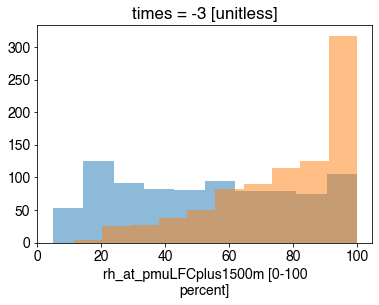

In [55]:
narrow_RHlfc1500_d4.plot.hist(alpha=0.5)
wide_RHlfc1500_d4.plot.hist(alpha=0.5)

## Make Pandas Data Frame for Correlograms

In [56]:
# Variable names to include in the Pandas Data Frame
names = ['Max 10dBZ ETH', 'Max dBZ', 'Lifetime', 'Max Diameter',
         'MU LNB', '$\sqrt{2*MUCAPE}$', '$\sqrt{2*(ACBL\ CAPE)}$', '$\sqrt{2*MUCIN}$', 'MU LCL Height', 'MU LFC Height', 'MU LCL Temp', 
         'TCWV', '500 hPa RH', 'ACBL RH', 'ACBL+1.5km RH',
         'ACBL BWD', '0-3 km BWD', '0-6 km BWD']

### Narrow cells

In [57]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d2 = pd.DataFrame(columns = names)

df_narrow_d2['Max 10dBZ ETH'] = narrow_maxETH10dbz_d2.data
df_narrow_d2['Max dBZ'] = narrow_maxdbz_d2.data
df_narrow_d2['Lifetime'] = narrow_track_lifetime_d2.data
df_narrow_d2['Max Diameter'] = narrow_maxdiam_d2.data
df_narrow_d2['MU LNB'] = narrow_pELmu_d2.data
df_narrow_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d2.data)
df_narrow_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d2.data)
df_narrow_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d2.data)
df_narrow_d2['MU LCL Height'] = narrow_LCLz_d2.data
df_narrow_d2['MU LFC Height'] = narrow_pLFCz_d2.data
df_narrow_d2['MU LCL Temp'] = narrow_LCLt_d2.data
df_narrow_d2['TCWV'] = narrow_PW_d2.data
df_narrow_d2['500 hPa RH'] = narrow_RH500mb_d2.data
# df_narrow_d2['600 hPa RH'] = narrow_RH600mb_d2.data
df_narrow_d2['ACBL RH'] = narrow_RHacbl_d2.data
df_narrow_d2['ACBL+1.5km RH'] = narrow_RHlfc1500_d2.data
df_narrow_d2['ACBL BWD'] = narrow_BWSacbl_d2.data
df_narrow_d2['0-3 km BWD'] = narrow_BWS03km_d2.data
df_narrow_d2['0-6 km BWD'] = narrow_BWS06km_d2.data

In [58]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d3 = pd.DataFrame(columns = names)

df_narrow_d3['Max 10dBZ ETH'] = narrow_maxETH10dbz_d3.data
df_narrow_d3['Max dBZ'] = narrow_maxdbz_d3.data
df_narrow_d3['Lifetime'] = narrow_track_lifetime_d3.data
df_narrow_d3['Max Diameter'] = narrow_maxdiam_d3.data
df_narrow_d3['MU LNB'] = narrow_pELmu_d3.data
df_narrow_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d3.data)
df_narrow_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d3.data)
df_narrow_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d3.data)
df_narrow_d3['MU LCL Height'] = narrow_LCLz_d3.data
df_narrow_d3['MU LFC Height'] = narrow_pLFCz_d3.data
df_narrow_d3['MU LCL Temp'] = narrow_LCLt_d3.data
df_narrow_d3['TCWV'] = narrow_PW_d3.data
df_narrow_d3['500 hPa RH'] = narrow_RH500mb_d3.data
# df_narrow_d3['600 hPa RH'] = narrow_RH600mb_d3.data
df_narrow_d3['ACBL RH'] = narrow_RHacbl_d3.data
df_narrow_d3['ACBL+1.5km RH'] = narrow_RHlfc1500_d3.data
df_narrow_d3['ACBL BWD'] = narrow_BWSacbl_d3.data
df_narrow_d3['0-3 km BWD'] = narrow_BWS03km_d3.data
df_narrow_d3['0-6 km BWD'] = narrow_BWS06km_d3.data

In [59]:
# Create Pandas Data Frames with variables for narrow cells
df_narrow_d4 = pd.DataFrame(columns = names)

df_narrow_d4['Max 10dBZ ETH'] = narrow_maxETH10dbz_d4.data
df_narrow_d4['Max dBZ'] = narrow_maxdbz_d4.data
df_narrow_d4['Lifetime'] = narrow_track_lifetime_d4.data
df_narrow_d4['Max Diameter'] = narrow_maxdiam_d4.data
df_narrow_d4['MU LNB'] = narrow_pELmu_d4.data
df_narrow_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*narrow_pCAPEmu_d4.data)
df_narrow_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*narrow_pCAPEacbl_d4.data)
df_narrow_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*narrow_pCINmu_d4.data)
df_narrow_d4['MU LCL Height'] = narrow_LCLz_d4.data
df_narrow_d4['MU LFC Height'] = narrow_pLFCz_d4.data
df_narrow_d4['MU LCL Temp'] = narrow_LCLt_d4.data
df_narrow_d4['TCWV'] = narrow_PW_d4.data
df_narrow_d4['500 hPa RH'] = narrow_RH500mb_d4.data
# df_narrow_d4['600 hPa RH'] = narrow_RH600mb_d4.data
df_narrow_d4['ACBL RH'] = narrow_RHacbl_d4.data
df_narrow_d4['ACBL+1.5km RH'] = narrow_RHlfc1500_d4.data
df_narrow_d4['ACBL BWD'] = narrow_BWSacbl_d4.data
df_narrow_d4['0-3 km BWD'] = narrow_BWS03km_d4.data
df_narrow_d4['0-6 km BWD'] = narrow_BWS06km_d4.data

### Wide cells

In [60]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d2 = pd.DataFrame(columns = names)

df_wide_d2['Max 10dBZ ETH'] = wide_maxETH10dbz_d2.data
df_wide_d2['Max dBZ'] = wide_maxdbz_d2.data
df_wide_d2['Lifetime'] = wide_track_lifetime_d2.data
df_wide_d2['Max Diameter'] = wide_maxdiam_d2.data
df_wide_d2['MU LNB'] = wide_pELmu_d2.data
df_wide_d2['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d2.data)
df_wide_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d2.data)
df_wide_d2['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d2.data)
df_wide_d2['MU LCL Height'] = wide_LCLz_d2.data
df_wide_d2['MU LFC Height'] = wide_pLFCz_d2.data
df_wide_d2['MU LCL Temp'] = wide_LCLt_d2.data
df_wide_d2['TCWV'] = wide_PW_d2.data
df_wide_d2['500 hPa RH'] = wide_RH500mb_d2.data
# df_wide_d2['600 hPa RH'] = wide_RH600mb_d2.data
df_wide_d2['ACBL RH'] = wide_RHacbl_d2.data
df_wide_d2['ACBL+1.5km RH'] = wide_RHlfc1500_d2.data
df_wide_d2['ACBL BWD'] = wide_BWSacbl_d2.data
df_wide_d2['0-3 km BWD'] = wide_BWS03km_d2.data
df_wide_d2['0-6 km BWD'] = wide_BWS06km_d2.data

In [61]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d3 = pd.DataFrame(columns = names)

df_wide_d3['Max 10dBZ ETH'] = wide_maxETH10dbz_d3.data
df_wide_d3['Max dBZ'] = wide_maxdbz_d3.data
df_wide_d3['Lifetime'] = wide_track_lifetime_d3.data
df_wide_d3['Max Diameter'] = wide_maxdiam_d3.data
df_wide_d3['MU LNB'] = wide_pELmu_d3.data
df_wide_d3['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d3.data)
df_wide_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d3.data)
df_wide_d3['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d3.data)
df_wide_d3['MU LCL Height'] = wide_LCLz_d3.data
df_wide_d3['MU LFC Height'] = wide_pLFCz_d3.data
df_wide_d3['MU LCL Temp'] = wide_LCLt_d3.data
df_wide_d3['TCWV'] = wide_PW_d3.data
df_wide_d3['500 hPa RH'] = wide_RH500mb_d3.data
# df_wide_d3['600 hPa RH'] = wide_RH600mb_d3.data
df_wide_d3['ACBL RH'] = wide_RHacbl_d3.data
df_wide_d3['ACBL+1.5km RH'] = wide_RHlfc1500_d3.data
df_wide_d3['ACBL BWD'] = wide_BWSacbl_d3.data
df_wide_d3['0-3 km BWD'] = wide_BWS03km_d3.data
df_wide_d3['0-6 km BWD'] = wide_BWS06km_d3.data

In [62]:
# Create Pandas Data Frames with variables for wide cells
df_wide_d4 = pd.DataFrame(columns = names)

df_wide_d4['Max 10dBZ ETH'] = wide_maxETH10dbz_d4.data
df_wide_d4['Max dBZ'] = wide_maxdbz_d4.data
df_wide_d4['Lifetime'] = wide_track_lifetime_d4.data
df_wide_d4['Max Diameter'] = wide_maxdiam_d4.data
df_wide_d4['MU LNB'] = wide_pELmu_d4.data
df_wide_d4['$\sqrt{2*MUCAPE}$'] = np.sqrt(2*wide_pCAPEmu_d4.data)
df_wide_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = np.sqrt(2*wide_pCAPEacbl_d4.data)
df_wide_d4['$\sqrt{2*MUCIN}$'] = np.sqrt(2*wide_pCINmu_d4.data)
df_wide_d4['MU LCL Height'] = wide_LCLz_d4.data
df_wide_d4['MU LFC Height'] = wide_pLFCz_d4.data
df_wide_d4['MU LCL Temp'] = wide_LCLt_d4.data
df_wide_d4['TCWV'] = wide_PW_d4.data
df_wide_d4['500 hPa RH'] = wide_RH500mb_d4.data
# df_wide_d4['600 hPa RH'] = wide_RH600mb_d4.data
df_wide_d4['ACBL RH'] = wide_RHacbl_d4.data
df_wide_d4['ACBL+1.5km RH'] = wide_RHlfc1500_d4.data
df_wide_d4['ACBL BWD'] = wide_BWSacbl_d4.data
df_wide_d4['0-3 km BWD'] = wide_BWS03km_d4.data
df_wide_d4['0-6 km BWD'] = wide_BWS06km_d4.data

In [63]:
# narrow_maxETH10dbz_d2.shape, narrow_maxdbz_d2.shape, narrow_track_lifetime_d2.shape, narrow_maxdiam_d2.shape

In [64]:
# narrow_pELmu_d2.shape, narrow_pCAPEmu_d2.shape, narrow_pCAPEacbl_d2.shape, narrow_pCINmu_d2.shape, narrow_LCLz_d2.shape, narrow_pLFCz_d2.shape, narrow_LCLt_d2.shape

## Functions to compute statistical significance

In [65]:
# def pearsonr_pvalues(df):
#     cols = pd.DataFrame(columns=df.columns)
#     p = cols.transpose().join(cols, how='outer')
#     for r in df.columns:
#         for c in df.columns:
#             tmp = df[df[r].notnull() & df[c].notnull()]
#             p[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
#     return p

In [66]:
# def spearmanr_pvalues(df):
#     cols = pd.DataFrame(columns=df.columns)
#     p = cols.transpose().join(cols, how='outer')
#     for r in df.columns:
#         for c in df.columns:
#             tmp = df[df[r].notnull() & df[c].notnull()]
#             p[r][c] = round(spearmanr(tmp[r], tmp[c])[1], 4)
#     return p

In [67]:
def pearsonr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            if not tmp.empty:
                # Calculate Pearson correlation and p-value, then assign the p-value
                correlation, p_value = pearsonr(tmp[r], tmp[c])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [68]:
def spearmanr_pvalues(df):
    # Create an empty DataFrame with the same columns and indices as 'df'
    p = pd.DataFrame(index=df.columns, columns=df.columns)
    
    # Iterate over each pair of columns
    for r in df.columns:
        for c in df.columns:
            # Filter rows where both columns have non-null values
            tmp = df[df[r].notnull() & df[c].notnull()]
            if not tmp.empty:
                # Calculate Spearman correlation and p-value, then assign the p-value
                correlation, p_value = spearmanr(tmp[r], tmp[c])
                p.loc[r, c] = round(p_value, 4)
    
    return p

In [69]:
# compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d2 = df_narrow_d2.corr(method='pearson')
corr_df_narrow_spearman_d2 = df_narrow_d2.corr(method='spearman')

corr_df_wide_pearson_d2 = df_wide_d2.corr(method='pearson')
corr_df_wide_spearman_d2 = df_wide_d2.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d2 = spearmanr_pvalues(df_narrow_d2)
p_df_narrow_pearson_d2 = pearsonr_pvalues(df_narrow_d2)

p_df_wide_spearman_d2 = spearmanr_pvalues(df_wide_d2)
p_df_wide_pearson_d2 = pearsonr_pvalues(df_wide_d2)

In [70]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d3 = df_narrow_d3.corr(method='pearson')
corr_df_narrow_spearman_d3 = df_narrow_d3.corr(method='spearman')

corr_df_wide_pearson_d3 = df_wide_d3.corr(method='pearson')
corr_df_wide_spearman_d3 = df_wide_d3.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d3 = spearmanr_pvalues(df_narrow_d3)
p_df_narrow_pearson_d3 = pearsonr_pvalues(df_narrow_d3)

p_df_wide_spearman_d3 = spearmanr_pvalues(df_wide_d3)
p_df_wide_pearson_d3 = pearsonr_pvalues(df_wide_d3)

In [71]:
#compute correlations between all pandas data frame variables
corr_df_narrow_pearson_d4 = df_narrow_d4.corr(method='pearson')
corr_df_narrow_spearman_d4 = df_narrow_d4.corr(method='spearman')

corr_df_wide_pearson_d4 = df_wide_d4.corr(method='pearson')
corr_df_wide_spearman_d4 = df_wide_d4.corr(method='spearman')

# Compute significance of correlations
p_df_narrow_spearman_d4 = spearmanr_pvalues(df_narrow_d4)
p_df_narrow_pearson_d4 = pearsonr_pvalues(df_narrow_d4)

p_df_wide_spearman_d4 = spearmanr_pvalues(df_wide_d4)
p_df_wide_pearson_d4 = pearsonr_pvalues(df_wide_d4)

In [72]:
#plot settings
# my_cmap = plt.cm.plasma
# my_cmap.set_under('w',1)
# %matplotlib inline

plt.rcParams.update({'font.size': 14})

import warnings
warnings.filterwarnings('ignore')

## D2 correlogram

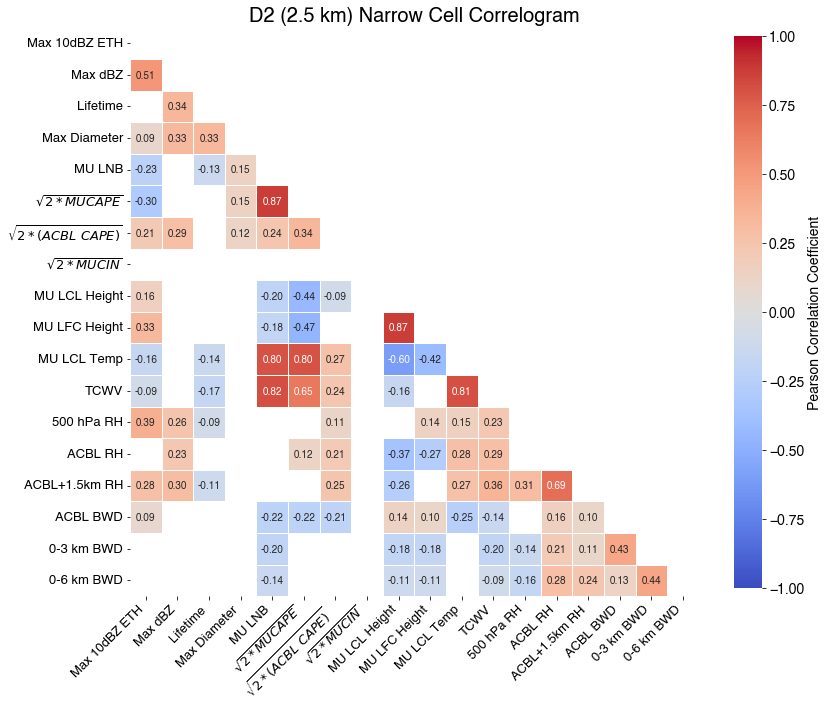

In [73]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d2, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_narrow_pearson_d2 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_narrow_pearson_d2, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D2 (2.5 km) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d2.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

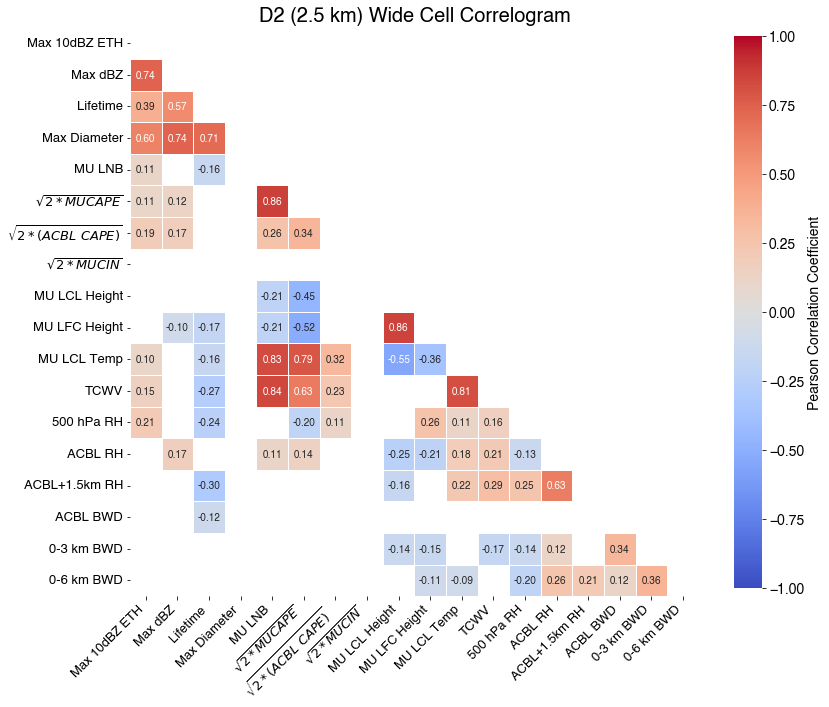

In [74]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d2, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_wide_pearson_d2 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_wide_pearson_d2, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D2 (2.5 km) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d2.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## D3 correlogram

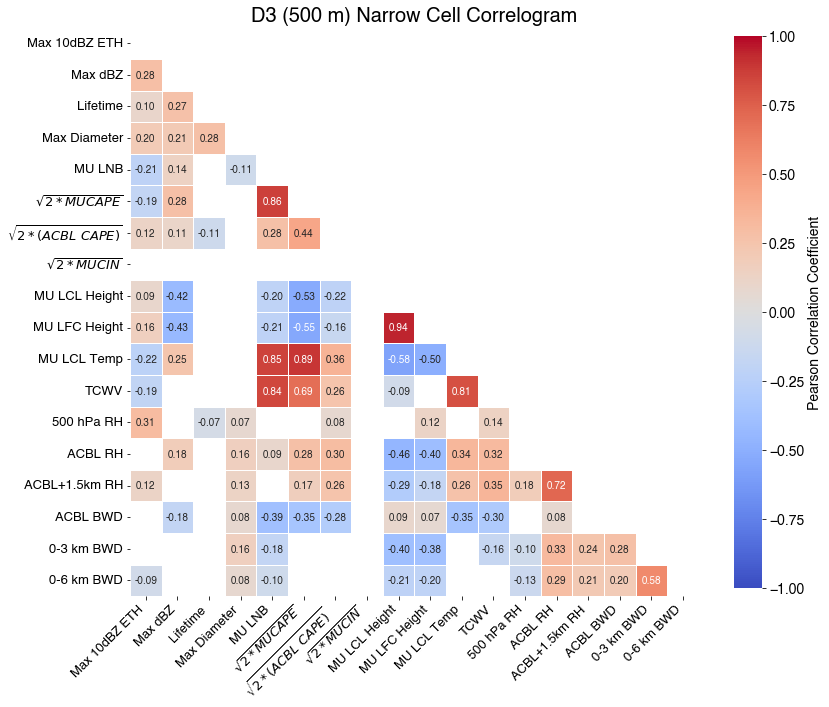

In [75]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d3, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_narrow_pearson_d3 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_narrow_pearson_d3, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D3 (500 m) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d3.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

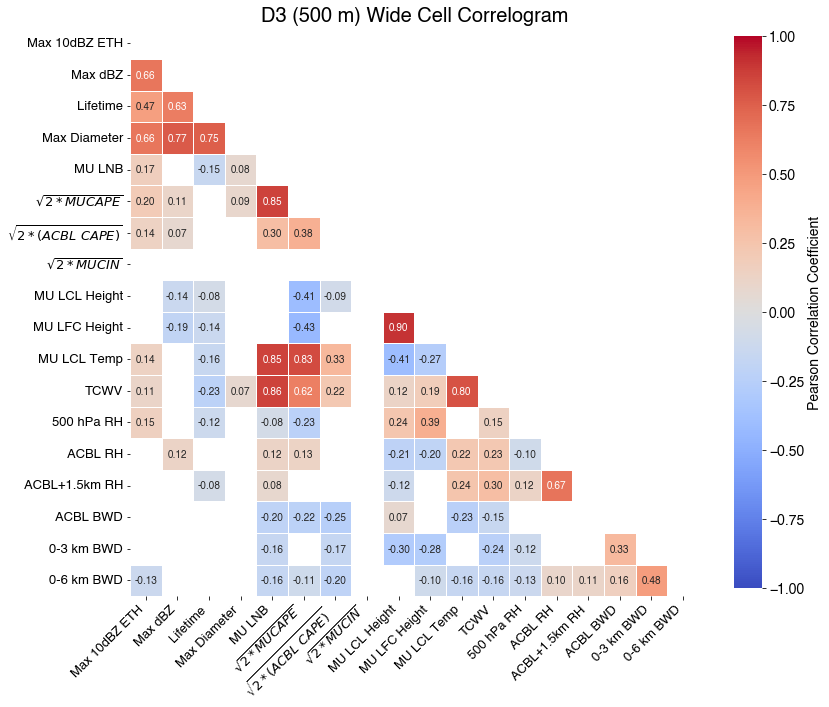

In [76]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d3, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_wide_pearson_d3 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_wide_pearson_d3, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D3 (500 m) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d3.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## D4 correlogram

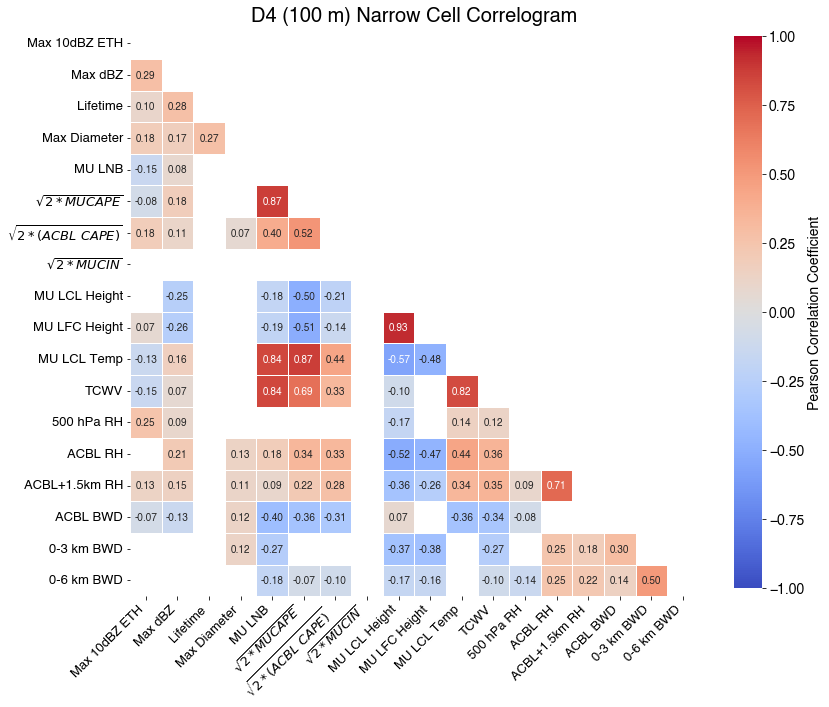

In [77]:
# narrow cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_narrow_spearman_d4, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_narrow_pearson_d4 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_narrow_pearson_d4, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D4 (100 m) Narrow Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_narrowcells_pearson_sig_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/correlogram_widecells_pearson_sig_d4.png


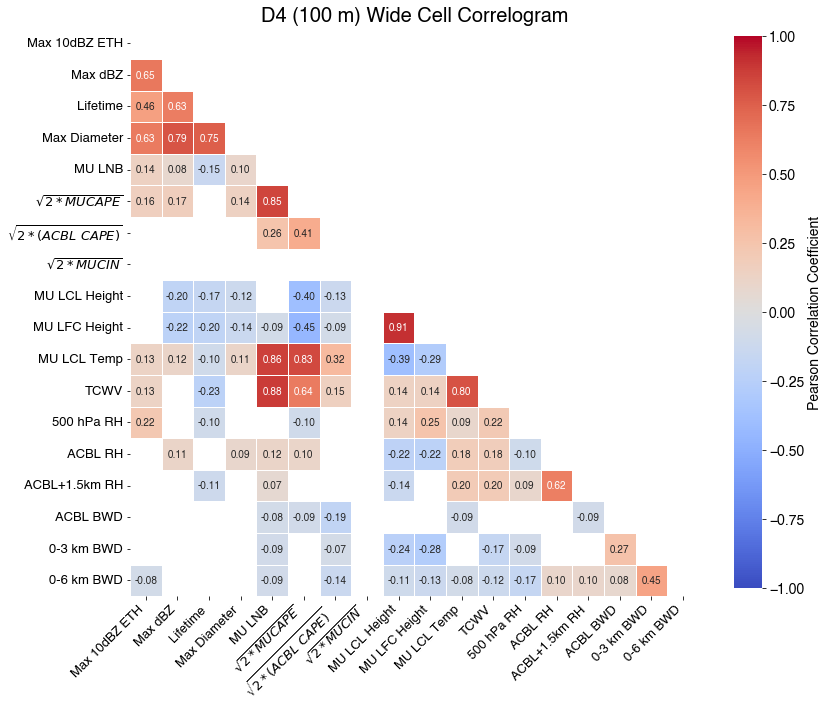

In [78]:
# wide cell correlogram using reversible ascent parameters/filters
fig, ax = plt.subplots(1,1, figsize=(12,12))
cmap = sns.color_palette("coolwarm", as_cmap=True)
pmask = np.triu(np.ones_like(corr_df_wide_spearman_d4, dtype=bool), k=0)
nonsigx, nonsigy = np.where(p_df_wide_pearson_d4 > 0.05)
pmask[nonsigx, nonsigy] = True
sns.heatmap(corr_df_wide_pearson_d4, 
            mask=pmask, 
            cmap=cmap, 
            vmax=1, 
            vmin=-1,
            center=0,
            square=True, 
            linewidths=.5,
            annot = True,
            fmt='.2f', 
            annot_kws={'size': 10},
            cbar_kws={"shrink": 0.7, "label": 'Pearson Correlation Coefficient'})
plt.xticks(rotation = 45, horizontalalignment = 'right')
ax.tick_params(axis = 'x', labelsize = 13)
ax.tick_params(axis = 'y', labelsize = 13)
ax.set_title('D4 (100 m) Wide Cell Correlogram', fontsize=20)

fig.tight_layout()
figname = f'{figdir}correlogram_widecells_pearson_sig_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
print(figname)

## Make Pandas Data Frame for Multi-Linear Regression (MLR)

### Narrow cells

In [79]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d2 = pd.DataFrame(columns = names)
df_narrow_std_d2['Max Diameter'] = ((narrow_maxdiam_d2 - np.nanmean(narrow_maxdiam_d2)) / np.nanstd(narrow_maxdiam_d2)).data
df_narrow_std_d2['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d2 - np.nanmean(narrow_maxETH10dbz_d2)) / np.nanstd(narrow_maxETH10dbz_d2)).data
df_narrow_std_d2['MU LNB'] = ((narrow_pELmu_d2 - np.nanmean(narrow_pELmu_d2)) / np.nanstd(narrow_pELmu_d2)).data
df_narrow_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d2))).data
df_narrow_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d2))).data
# df_narrow_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d2) - np.nanmean(np.sqrt(2*narrow_pCINmu_d2))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d2))).data
df_narrow_std_d2['MU LCL Height'] = ((narrow_LCLz_d2 - np.nanmean(narrow_LCLz_d2)) / np.nanstd(narrow_LCLz_d2)).data
df_narrow_std_d2['MU LFC Height'] = ((narrow_pLFCz_d2 - np.nanmean(narrow_pLFCz_d2)) / np.nanstd(narrow_pLFCz_d2)).data
df_narrow_std_d2['MU LCL Temp'] = ((narrow_LCLt_d2 - np.nanmean(narrow_LCLt_d2)) / np.nanstd(narrow_LCLt_d2)).data
df_narrow_std_d2['TCWV'] = ((narrow_PW_d2 - np.nanmean(narrow_PW_d2)) / np.nanstd(narrow_PW_d2)).data
df_narrow_std_d2['500 hPa RH'] = ((narrow_RH500mb_d2 - np.nanmean(narrow_RH500mb_d2)) / np.nanstd(narrow_RH500mb_d2)).data
# df_narrow_std_d2['ACBL RH'] = ((narrow_RHacbl_d2 - np.nanmean(narrow_RHacbl_d2)) / np.nanstd(narrow_RHacbl_d2)).data
df_narrow_std_d2['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d2 - np.nanmean(narrow_RHlfc1500_d2)) / np.nanstd(narrow_RHlfc1500_d2)).data
df_narrow_std_d2['ACBL BWD'] = ((narrow_BWSacbl_d2 - np.nanmean(narrow_BWSacbl_d2)) / np.nanstd(narrow_BWSacbl_d2)).data
df_narrow_std_d2['0-3 km BWD'] = ((narrow_BWS03km_d2 - np.nanmean(narrow_BWS03km_d2)) / np.nanstd(narrow_BWS03km_d2)).data
df_narrow_std_d2['0-6 km BWD'] = ((narrow_BWS06km_d2 - np.nanmean(narrow_BWS06km_d2)) / np.nanstd(narrow_BWS06km_d2)).data

In [80]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d3 = pd.DataFrame(columns = names)
df_narrow_std_d3['Max Diameter'] = ((narrow_maxdiam_d3 - np.nanmean(narrow_maxdiam_d3)) / np.nanstd(narrow_maxdiam_d3)).data
df_narrow_std_d3['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d3 - np.nanmean(narrow_maxETH10dbz_d3)) / np.nanstd(narrow_maxETH10dbz_d3)).data
df_narrow_std_d3['MU LNB'] = ((narrow_pELmu_d3 - np.nanmean(narrow_pELmu_d3)) / np.nanstd(narrow_pELmu_d3)).data
df_narrow_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d3))).data
df_narrow_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d3))).data
# df_narrow_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d3) - np.nanmean(np.sqrt(2*narrow_pCINmu_d3))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d3))).data
df_narrow_std_d3['MU LCL Height'] = ((narrow_LCLz_d3 - np.nanmean(narrow_LCLz_d3)) / np.nanstd(narrow_LCLz_d3)).data
df_narrow_std_d3['MU LFC Height'] = ((narrow_pLFCz_d3 - np.nanmean(narrow_pLFCz_d3)) / np.nanstd(narrow_pLFCz_d3)).data
df_narrow_std_d3['MU LCL Temp'] = ((narrow_LCLt_d3 - np.nanmean(narrow_LCLt_d3)) / np.nanstd(narrow_LCLt_d3)).data
df_narrow_std_d3['TCWV'] = ((narrow_PW_d3 - np.nanmean(narrow_PW_d3)) / np.nanstd(narrow_PW_d3)).data
df_narrow_std_d3['500 hPa RH'] = ((narrow_RH500mb_d3 - np.nanmean(narrow_RH500mb_d3)) / np.nanstd(narrow_RH500mb_d3)).data
# df_narrow_std_d3['ACBL RH'] = ((narrow_RHacbl_d3 - np.nanmean(narrow_RHacbl_d3)) / np.nanstd(narrow_RHacbl_d3)).data
df_narrow_std_d3['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d3 - np.nanmean(narrow_RHlfc1500_d3)) / np.nanstd(narrow_RHlfc1500_d3)).data
df_narrow_std_d3['ACBL BWD'] = ((narrow_BWSacbl_d3 - np.nanmean(narrow_BWSacbl_d3)) / np.nanstd(narrow_BWSacbl_d3)).data
df_narrow_std_d3['0-3 km BWD'] = ((narrow_BWS03km_d3 - np.nanmean(narrow_BWS03km_d3)) / np.nanstd(narrow_BWS03km_d3)).data
df_narrow_std_d3['0-6 km BWD'] = ((narrow_BWS06km_d3 - np.nanmean(narrow_BWS06km_d3)) / np.nanstd(narrow_BWS06km_d3)).data

In [81]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_narrow_std_d4 = pd.DataFrame(columns = names)
df_narrow_std_d4['Max Diameter'] = ((narrow_maxdiam_d4 - np.nanmean(narrow_maxdiam_d4)) / np.nanstd(narrow_maxdiam_d4)).data
df_narrow_std_d4['Max 10dBZ ETH'] = ((narrow_maxETH10dbz_d4 - np.nanmean(narrow_maxETH10dbz_d4)) / np.nanstd(narrow_maxETH10dbz_d4)).data
df_narrow_std_d4['MU LNB'] = ((narrow_pELmu_d4 - np.nanmean(narrow_pELmu_d4)) / np.nanstd(narrow_pELmu_d4)).data
df_narrow_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*narrow_pCAPEmu_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEmu_d4))).data
df_narrow_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*narrow_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*narrow_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*narrow_pCAPEacbl_d4))).data
# df_narrow_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*narrow_pCINmu_d4) - np.nanmean(np.sqrt(2*narrow_pCINmu_d4))) / np.nanstd(np.sqrt(2*narrow_pCINmu_d4))).data
df_narrow_std_d4['MU LCL Height'] = ((narrow_LCLz_d4 - np.nanmean(narrow_LCLz_d4)) / np.nanstd(narrow_LCLz_d4)).data
df_narrow_std_d4['MU LFC Height'] = ((narrow_pLFCz_d4 - np.nanmean(narrow_pLFCz_d4)) / np.nanstd(narrow_pLFCz_d4)).data
df_narrow_std_d4['MU LCL Temp'] = ((narrow_LCLt_d4 - np.nanmean(narrow_LCLt_d4)) / np.nanstd(narrow_LCLt_d4)).data
df_narrow_std_d4['TCWV'] = ((narrow_PW_d4 - np.nanmean(narrow_PW_d4)) / np.nanstd(narrow_PW_d4)).data
df_narrow_std_d4['500 hPa RH'] = ((narrow_RH500mb_d4 - np.nanmean(narrow_RH500mb_d4)) / np.nanstd(narrow_RH500mb_d4)).data
# df_narrow_std_d4['ACBL RH'] = ((narrow_RHacbl_d4 - np.nanmean(narrow_RHacbl_d4)) / np.nanstd(narrow_RHacbl_d4)).data
df_narrow_std_d4['ACBL+1.5km RH'] = ((narrow_RHlfc1500_d4 - np.nanmean(narrow_RHlfc1500_d4)) / np.nanstd(narrow_RHlfc1500_d4)).data
df_narrow_std_d4['ACBL BWD'] = ((narrow_BWSacbl_d4 - np.nanmean(narrow_BWSacbl_d4)) / np.nanstd(narrow_BWSacbl_d4)).data
df_narrow_std_d4['0-3 km BWD'] = ((narrow_BWS03km_d4 - np.nanmean(narrow_BWS03km_d4)) / np.nanstd(narrow_BWS03km_d4)).data
df_narrow_std_d4['0-6 km BWD'] = ((narrow_BWS06km_d4 - np.nanmean(narrow_BWS06km_d4)) / np.nanstd(narrow_BWS06km_d4)).data

### Wide cells

In [82]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d2 = pd.DataFrame(columns = names)
df_wide_std_d2['Max Diameter'] = ((wide_maxdiam_d2 - np.nanmean(wide_maxdiam_d2)) / np.nanstd(wide_maxdiam_d2)).data
df_wide_std_d2['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d2 - np.nanmean(wide_maxETH10dbz_d2)) / np.nanstd(wide_maxETH10dbz_d2)).data
df_wide_std_d2['MU LNB'] = ((wide_pELmu_d2 - np.nanmean(wide_pELmu_d2)) / np.nanstd(wide_pELmu_d2)).data
df_wide_std_d2['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d2) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d2))).data
df_wide_std_d2['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d2) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d2))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d2))).data
# df_wide_std_d2['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d2) - np.nanmean(np.sqrt(2*wide_pCINmu_d2))) / np.nanstd(np.sqrt(2*wide_pCINmu_d2))).data
df_wide_std_d2['MU LCL Height'] = ((wide_LCLz_d2 - np.nanmean(wide_LCLz_d2)) / np.nanstd(wide_LCLz_d2)).data
df_wide_std_d2['MU LFC Height'] = ((wide_pLFCz_d2 - np.nanmean(wide_pLFCz_d2)) / np.nanstd(wide_pLFCz_d2)).data
df_wide_std_d2['MU LCL Temp'] = ((wide_LCLt_d2 - np.nanmean(wide_LCLt_d2)) / np.nanstd(wide_LCLt_d2)).data
df_wide_std_d2['TCWV'] = ((wide_PW_d2 - np.nanmean(wide_PW_d2)) / np.nanstd(wide_PW_d2)).data
df_wide_std_d2['500 hPa RH'] = ((wide_RH500mb_d2 - np.nanmean(wide_RH500mb_d2)) / np.nanstd(wide_RH500mb_d2)).data
# df_wide_std_d2['ACBL RH'] = ((wide_RHacbl_d2 - np.nanmean(wide_RHacbl_d2)) / np.nanstd(wide_RHacbl_d2)).data
df_wide_std_d2['ACBL+1.5km RH'] = ((wide_RHlfc1500_d2 - np.nanmean(wide_RHlfc1500_d2)) / np.nanstd(wide_RHlfc1500_d2)).data
df_wide_std_d2['ACBL BWD'] = ((wide_BWSacbl_d2 - np.nanmean(wide_BWSacbl_d2)) / np.nanstd(wide_BWSacbl_d2)).data
df_wide_std_d2['0-3 km BWD'] = ((wide_BWS03km_d2 - np.nanmean(wide_BWS03km_d2)) / np.nanstd(wide_BWS03km_d2)).data
df_wide_std_d2['0-6 km BWD'] = ((wide_BWS06km_d2 - np.nanmean(wide_BWS06km_d2)) / np.nanstd(wide_BWS06km_d2)).data

In [83]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d3 = pd.DataFrame(columns = names)
df_wide_std_d3['Max Diameter'] = ((wide_maxdiam_d3 - np.nanmean(wide_maxdiam_d3)) / np.nanstd(wide_maxdiam_d3)).data
df_wide_std_d3['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d3 - np.nanmean(wide_maxETH10dbz_d3)) / np.nanstd(wide_maxETH10dbz_d3)).data
df_wide_std_d3['MU LNB'] = ((wide_pELmu_d3 - np.nanmean(wide_pELmu_d3)) / np.nanstd(wide_pELmu_d3)).data
df_wide_std_d3['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d3) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d3))).data
df_wide_std_d3['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d3) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d3))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d3))).data
# df_wide_std_d3['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d3) - np.nanmean(np.sqrt(2*wide_pCINmu_d3))) / np.nanstd(np.sqrt(2*wide_pCINmu_d3))).data
df_wide_std_d3['MU LCL Height'] = ((wide_LCLz_d3 - np.nanmean(wide_LCLz_d3)) / np.nanstd(wide_LCLz_d3)).data
df_wide_std_d3['MU LFC Height'] = ((wide_pLFCz_d3 - np.nanmean(wide_pLFCz_d3)) / np.nanstd(wide_pLFCz_d3)).data
df_wide_std_d3['MU LCL Temp'] = ((wide_LCLt_d3 - np.nanmean(wide_LCLt_d3)) / np.nanstd(wide_LCLt_d3)).data
df_wide_std_d3['TCWV'] = ((wide_PW_d3 - np.nanmean(wide_PW_d3)) / np.nanstd(wide_PW_d3)).data
df_wide_std_d3['500 hPa RH'] = ((wide_RH500mb_d3 - np.nanmean(wide_RH500mb_d3)) / np.nanstd(wide_RH500mb_d3)).data
# df_wide_std_d3['ACBL RH'] = ((wide_RHacbl_d3 - np.nanmean(wide_RHacbl_d3)) / np.nanstd(wide_RHacbl_d3)).data
df_wide_std_d3['ACBL+1.5km RH'] = ((wide_RHlfc1500_d3 - np.nanmean(wide_RHlfc1500_d3)) / np.nanstd(wide_RHlfc1500_d3)).data
df_wide_std_d3['ACBL BWD'] = ((wide_BWSacbl_d3 - np.nanmean(wide_BWSacbl_d3)) / np.nanstd(wide_BWSacbl_d3)).data
df_wide_std_d3['0-3 km BWD'] = ((wide_BWS03km_d3 - np.nanmean(wide_BWS03km_d3)) / np.nanstd(wide_BWS03km_d3)).data
df_wide_std_d3['0-6 km BWD'] = ((wide_BWS06km_d3 - np.nanmean(wide_BWS06km_d3)) / np.nanstd(wide_BWS06km_d3)).data

In [84]:
# define new pandas data frames with standardized variables (variables values on a scale of # of standard deviations)
df_wide_std_d4 = pd.DataFrame(columns = names)
df_wide_std_d4['Max Diameter'] = ((wide_maxdiam_d4 - np.nanmean(wide_maxdiam_d4)) / np.nanstd(wide_maxdiam_d4)).data
df_wide_std_d4['Max 10dBZ ETH'] = ((wide_maxETH10dbz_d4 - np.nanmean(wide_maxETH10dbz_d4)) / np.nanstd(wide_maxETH10dbz_d4)).data
df_wide_std_d4['MU LNB'] = ((wide_pELmu_d4 - np.nanmean(wide_pELmu_d4)) / np.nanstd(wide_pELmu_d4)).data
df_wide_std_d4['$\sqrt{2*MUCAPE}$'] = ((np.sqrt(2*wide_pCAPEmu_d4) - np.nanmean(np.sqrt(2*wide_pCAPEmu_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEmu_d4))).data
df_wide_std_d4['$\sqrt{2*(ACBL\ CAPE)}$'] = ((np.sqrt(2*wide_pCAPEacbl_d4) - np.nanmean(np.sqrt(2*wide_pCAPEacbl_d4))) / np.nanstd(np.sqrt(2*wide_pCAPEacbl_d4))).data
# df_wide_std_d4['$\sqrt{2*MUCIN}$'] = ((np.sqrt(2*wide_pCINmu_d4) - np.nanmean(np.sqrt(2*wide_pCINmu_d4))) / np.nanstd(np.sqrt(2*wide_pCINmu_d4))).data
df_wide_std_d4['MU LCL Height'] = ((wide_LCLz_d4 - np.nanmean(wide_LCLz_d4)) / np.nanstd(wide_LCLz_d4)).data
df_wide_std_d4['MU LFC Height'] = ((wide_pLFCz_d4 - np.nanmean(wide_pLFCz_d4)) / np.nanstd(wide_pLFCz_d4)).data
df_wide_std_d4['MU LCL Temp'] = ((wide_LCLt_d4 - np.nanmean(wide_LCLt_d4)) / np.nanstd(wide_LCLt_d4)).data
df_wide_std_d4['TCWV'] = ((wide_PW_d4 - np.nanmean(wide_PW_d4)) / np.nanstd(wide_PW_d4)).data
df_wide_std_d4['500 hPa RH'] = ((wide_RH500mb_d4 - np.nanmean(wide_RH500mb_d4)) / np.nanstd(wide_RH500mb_d4)).data
# df_wide_std_d4['ACBL RH'] = ((wide_RHacbl_d4 - np.nanmean(wide_RHacbl_d4)) / np.nanstd(wide_RHacbl_d4)).data
df_wide_std_d4['ACBL+1.5km RH'] = ((wide_RHlfc1500_d4 - np.nanmean(wide_RHlfc1500_d4)) / np.nanstd(wide_RHlfc1500_d4)).data
df_wide_std_d4['ACBL BWD'] = ((wide_BWSacbl_d4 - np.nanmean(wide_BWSacbl_d4)) / np.nanstd(wide_BWSacbl_d4)).data
df_wide_std_d4['0-3 km BWD'] = ((wide_BWS03km_d4 - np.nanmean(wide_BWS03km_d4)) / np.nanstd(wide_BWS03km_d4)).data
df_wide_std_d4['0-6 km BWD'] = ((wide_BWS06km_d4 - np.nanmean(wide_BWS06km_d4)) / np.nanstd(wide_BWS06km_d4)).data

(array([21., 42., 58., 70., 62., 34., 40., 32., 35., 52.]),
 array([-1.8328047 , -1.4672749 , -1.101745  , -0.73621523, -0.3706854 ,
        -0.00515556,  0.36037427,  0.7259041 ,  1.0914339 ,  1.4569638 ,
         1.8224936 ], dtype=float32),
 <BarContainer object of 10 artists>)

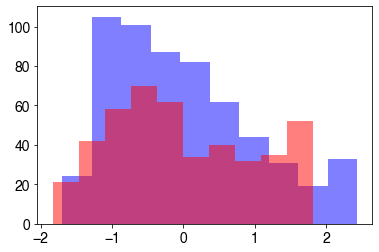

In [85]:
# ((narrow_maxdiam_d2 - np.nanmean(narrow_maxdiam_d2)) / np.nanstd(narrow_maxdiam_d2)).data
# plt.hist(df_narrow_std_d2['Max 10dBZ ETH'].values)
plt.hist(df_narrow_std_d2['500 hPa RH'].values, color='b', alpha=0.5)
plt.hist(df_wide_std_d2['500 hPa RH'].values, color='r', alpha=0.5)

# Calculate multivariate linear regression

## Prediction including using cell diameter

### Narrow cells

In [86]:
names

['Max 10dBZ ETH',
 'Max dBZ',
 'Lifetime',
 'Max Diameter',
 'MU LNB',
 '$\\sqrt{2*MUCAPE}$',
 '$\\sqrt{2*(ACBL\\ CAPE)}$',
 '$\\sqrt{2*MUCIN}$',
 'MU LCL Height',
 'MU LFC Height',
 'MU LCL Temp',
 'TCWV',
 '500 hPa RH',
 'ACBL RH',
 'ACBL+1.5km RH',
 'ACBL BWD',
 '0-3 km BWD',
 '0-6 km BWD']

In [87]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_all = ['Max Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
predictors_all = ['Max Diameter', 'MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '500 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
X = df_narrow_std_d2[predictors_all].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
# #lm_narrow_std_all_eth = pg.linear_regression(X, Y, remove_na=True, weights=weights).round(3)
lm_narrow_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.034,-0.000,1.000,0.341,0.331,-0.066,0.066,NaN,NaN
1,x1,0.120,0.035,3.472,0.001,0.341,0.331,0.052,0.188,0.013,3.925
2,x2,-0.015,0.109,-0.133,0.894,0.341,0.331,-0.228,0.199,0.021,6.245
3,x3,0.027,0.091,0.297,0.766,0.341,0.331,-0.151,0.205,0.032,9.325
4,x4,-0.238,0.077,-3.075,0.002,0.341,0.331,-0.390,-0.086,0.023,6.834
5,x5,0.504,0.080,6.298,0.000,0.341,0.331,0.347,0.661,0.072,21.164
6,x6,-0.275,0.079,-3.468,0.001,0.341,0.331,-0.430,-0.119,0.015,4.257
7,x7,0.287,0.039,7.444,0.000,0.341,0.331,0.212,0.363,0.104,30.595
8,x8,0.265,0.049,5.449,0.000,0.341,0.331,0.170,0.361,0.059,17.176
9,x9,-0.014,0.037,-0.369,0.712,0.341,0.331,-0.085,0.058,0.002,0.480


In [88]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_all].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.030,-0.000,1.000,0.27,0.262,-0.059,0.059,NaN,NaN
1,x1,0.148,0.031,4.856,0.000,0.27,0.262,0.088,0.208,0.028,10.519
2,x2,0.212,0.106,2.009,0.045,0.27,0.262,0.005,0.419,0.020,7.567
3,x3,0.259,0.090,2.874,0.004,0.27,0.262,0.082,0.437,0.015,5.596
4,x4,-0.373,0.100,-3.730,0.000,0.27,0.262,-0.569,-0.177,0.014,5.283
5,x5,0.686,0.105,6.543,0.000,0.27,0.262,0.480,0.892,0.033,12.162
6,x6,-0.691,0.079,-8.793,0.000,0.27,0.262,-0.845,-0.537,0.046,17.090
7,x7,0.263,0.033,8.060,0.000,0.27,0.262,0.199,0.327,0.078,28.724
8,x8,0.277,0.043,6.469,0.000,0.27,0.262,0.193,0.362,0.028,10.218
9,x9,-0.075,0.032,-2.346,0.019,0.27,0.262,-0.138,-0.012,0.008,2.840


In [89]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_all].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.030,-0.000,1.000,0.223,0.215,-0.059,0.059,NaN,NaN
1,x1,0.162,0.031,5.305,0.000,0.223,0.215,0.102,0.222,0.029,13.172
2,x2,0.129,0.107,1.201,0.230,0.223,0.215,-0.082,0.339,0.014,6.478
3,x3,0.297,0.089,3.342,0.001,0.223,0.215,0.123,0.471,0.011,4.876
4,x4,-0.302,0.092,-3.267,0.001,0.223,0.215,-0.483,-0.121,0.011,5.034
5,x5,0.597,0.093,6.430,0.000,0.223,0.215,0.414,0.779,0.025,11.031
6,x6,-0.600,0.076,-7.880,0.000,0.223,0.215,-0.750,-0.451,0.035,15.713
7,x7,0.275,0.033,8.401,0.000,0.223,0.215,0.211,0.339,0.066,29.553
8,x8,0.280,0.042,6.739,0.000,0.223,0.215,0.199,0.362,0.030,13.258
9,x9,-0.028,0.033,-0.846,0.398,0.223,0.215,-0.091,0.036,0.002,0.886


### Wide cells

In [90]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_all].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.035,0.000,1.000,0.467,0.456,-0.069,0.069,NaN,NaN
1,x1,0.631,0.035,17.834,0.000,0.467,0.456,0.562,0.701,0.383,82.007
2,x2,-0.072,0.121,-0.593,0.553,0.467,0.456,-0.309,0.166,0.006,1.305
3,x3,0.231,0.096,2.405,0.017,0.467,0.456,0.042,0.420,0.010,2.103
4,x4,-0.022,0.078,-0.283,0.777,0.467,0.456,-0.176,0.132,0.002,0.382
5,x5,0.150,0.086,1.737,0.083,0.467,0.456,-0.020,0.319,0.005,1.105
6,x6,0.042,0.089,0.472,0.637,0.467,0.456,-0.133,0.217,0.010,2.145
7,x7,0.229,0.041,5.524,0.000,0.467,0.456,0.147,0.310,0.044,9.429
8,x8,0.071,0.047,1.514,0.131,0.467,0.456,-0.021,0.163,0.005,1.178
9,x9,-0.024,0.039,-0.613,0.540,0.467,0.456,-0.100,0.052,0.002,0.346


In [91]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_all].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.025,0.000,1.000,0.505,0.5,-0.048,0.048,NaN,NaN
1,x1,0.643,0.025,25.837,0.000,0.505,0.5,0.595,0.692,0.416,82.303
2,x2,0.066,0.089,0.741,0.459,0.505,0.5,-0.109,0.240,0.011,2.216
3,x3,0.275,0.071,3.868,0.000,0.505,0.5,0.136,0.415,0.022,4.301
4,x4,-0.011,0.062,-0.184,0.854,0.505,0.5,-0.133,0.110,0.002,0.412
5,x5,0.061,0.070,0.878,0.380,0.505,0.5,-0.076,0.198,0.003,0.596
6,x6,-0.199,0.065,-3.079,0.002,0.505,0.5,-0.326,-0.072,0.007,1.419
7,x7,0.217,0.029,7.445,0.000,0.505,0.5,0.160,0.274,0.033,6.468
8,x8,-0.044,0.029,-1.478,0.140,0.505,0.5,-0.101,0.014,0.003,0.603
9,x9,-0.062,0.026,-2.403,0.016,0.505,0.5,-0.112,-0.011,0.008,1.681


In [92]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_all].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()

lm_wide_std_all_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_all_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.025,0.000,1.000,0.461,0.455,-0.049,0.049,NaN,NaN
1,x1,0.620,0.025,24.455,0.000,0.461,0.455,0.571,0.670,0.385,83.514
2,x2,-0.086,0.086,-0.995,0.320,0.461,0.455,-0.256,0.084,0.006,1.356
3,x3,0.216,0.068,3.160,0.002,0.461,0.455,0.082,0.351,0.012,2.531
4,x4,0.066,0.063,1.040,0.299,0.461,0.455,-0.058,0.189,0.001,0.303
5,x5,0.014,0.068,0.212,0.832,0.461,0.455,-0.118,0.147,0.002,0.374
6,x6,-0.029,0.066,-0.439,0.661,0.461,0.455,-0.158,0.100,0.005,1.100
7,x7,0.231,0.028,8.207,0.000,0.461,0.455,0.175,0.286,0.046,10.056
8,x8,0.004,0.028,0.130,0.897,0.461,0.455,-0.051,0.058,0.000,0.048
9,x9,-0.032,0.026,-1.245,0.213,0.461,0.455,-0.083,0.018,0.003,0.719


## Prediction using environmental variables only

### Narrow cells

In [93]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
# predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
predictors_subset = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', 'MU LFC Height', 'TCWV', '500 hPa RH', 'ACBL+1.5km RH', '0-6 km BWD']
X = df_narrow_std_d2[predictors_subset].to_numpy()
Y = df_narrow_std_d2['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_subset_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_subset_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.034,-0.000,1.000,0.328,0.318,-0.067,0.067,NaN,NaN
1,x1,0.015,0.110,0.135,0.892,0.328,0.318,-0.200,0.230,0.020,6.239
2,x2,0.043,0.092,0.474,0.636,0.328,0.318,-0.136,0.223,0.031,9.399
3,x3,-0.223,0.078,-2.859,0.004,0.328,0.318,-0.376,-0.070,0.023,7.015
4,x4,0.500,0.081,6.190,0.000,0.328,0.318,0.341,0.659,0.072,22.023
5,x5,-0.305,0.080,-3.831,0.000,0.328,0.318,-0.461,-0.148,0.015,4.601
6,x6,0.295,0.039,7.581,0.000,0.328,0.318,0.219,0.371,0.106,32.348
7,x7,0.271,0.049,5.528,0.000,0.328,0.318,0.175,0.368,0.059,17.865
8,x8,-0.015,0.037,-0.416,0.677,0.328,0.318,-0.088,0.057,0.002,0.510


In [94]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d3[predictors_subset].to_numpy()
Y = df_narrow_std_d3['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_subset_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_subset_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.030,-0.000,1.000,0.249,0.242,-0.060,0.060,NaN,NaN
1,x1,0.170,0.107,1.595,0.111,0.249,0.242,-0.039,0.379,0.021,8.577
2,x2,0.287,0.091,3.148,0.002,0.249,0.242,0.108,0.467,0.016,6.406
3,x3,-0.378,0.101,-3.730,0.000,0.249,0.242,-0.577,-0.179,0.015,5.837
4,x4,0.694,0.106,6.530,0.000,0.249,0.242,0.485,0.903,0.033,13.307
5,x5,-0.688,0.080,-8.637,0.000,0.249,0.242,-0.844,-0.532,0.047,18.707
6,x6,0.272,0.033,8.238,0.000,0.249,0.242,0.207,0.337,0.080,32.269
7,x7,0.290,0.043,6.672,0.000,0.249,0.242,0.204,0.375,0.030,12.044
8,x8,-0.070,0.032,-2.149,0.032,0.249,0.242,-0.133,-0.006,0.007,2.855


In [95]:
# Multivariate linear regression using reduced set of predictors including max diameter for narrow cells
X = df_narrow_std_d4[predictors_subset].to_numpy()
Y = df_narrow_std_d4['Max 10dBZ ETH'].to_numpy()

lm_narrow_std_subset_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_narrow_std_subset_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,0.000,0.031,0.000,1.000,0.198,0.19,-0.060,0.060,NaN,NaN
1,x1,0.102,0.109,0.942,0.347,0.198,0.19,-0.111,0.316,0.015,7.670
2,x2,0.327,0.090,3.631,0.000,0.198,0.19,0.150,0.503,0.012,5.991
3,x3,-0.295,0.094,-3.147,0.002,0.198,0.19,-0.480,-0.111,0.011,5.709
4,x4,0.604,0.094,6.415,0.000,0.198,0.19,0.420,0.789,0.025,12.680
5,x5,-0.608,0.077,-7.852,0.000,0.198,0.19,-0.760,-0.456,0.036,18.128
6,x6,0.267,0.033,8.038,0.000,0.198,0.19,0.202,0.332,0.064,32.267
7,x7,0.302,0.042,7.169,0.000,0.198,0.19,0.219,0.384,0.033,16.657
8,x8,-0.024,0.033,-0.714,0.475,0.198,0.19,-0.088,0.041,0.002,0.898


### Wide cells

In [96]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d2[predictors_subset].to_numpy()
Y = df_wide_std_d2['Max 10dBZ ETH'].to_numpy()

lm_wide_std_subset_eth_d2 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_subset_eth_d2

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.046,-0.000,1.000,0.078,0.061,-0.090,0.090,NaN,NaN
1,x1,-0.105,0.159,-0.658,0.511,0.078,0.061,-0.417,0.208,0.006,7.864
2,x2,0.309,0.126,2.453,0.015,0.078,0.061,0.061,0.557,0.012,16.021
3,x3,0.092,0.103,0.895,0.371,0.078,0.061,-0.110,0.294,0.002,2.271
4,x4,0.038,0.113,0.341,0.733,0.078,0.061,-0.183,0.260,0.003,3.666
5,x5,-0.002,0.117,-0.020,0.984,0.078,0.061,-0.232,0.228,0.008,10.656
6,x6,0.232,0.054,4.254,0.000,0.078,0.061,0.125,0.338,0.041,53.234
7,x7,0.056,0.062,0.908,0.365,0.078,0.061,-0.065,0.177,0.004,4.828
8,x8,-0.013,0.051,-0.262,0.794,0.078,0.061,-0.113,0.087,0.001,1.461


In [97]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d3[predictors_subset].to_numpy()
Y = df_wide_std_d3['Max 10dBZ ETH'].to_numpy()

lm_wide_std_subset_eth_d3 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_subset_eth_d3

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.033,-0.000,1.000,0.099,0.09,-0.065,0.065,NaN,NaN
1,x1,0.049,0.120,0.409,0.683,0.099,0.09,-0.186,0.284,0.012,12.462
2,x2,0.303,0.096,3.156,0.002,0.099,0.09,0.114,0.491,0.025,24.924
3,x3,0.103,0.083,1.237,0.216,0.099,0.09,-0.060,0.267,0.003,2.595
4,x4,-0.097,0.094,-1.039,0.299,0.099,0.09,-0.281,0.086,0.004,3.641
5,x5,-0.154,0.087,-1.766,0.078,0.099,0.09,-0.325,0.017,0.007,6.992
6,x6,0.251,0.039,6.382,0.000,0.099,0.09,0.174,0.328,0.037,37.376
7,x7,-0.020,0.040,-0.494,0.621,0.099,0.09,-0.098,0.058,0.002,2.062
8,x8,-0.081,0.035,-2.330,0.020,0.099,0.09,-0.149,-0.013,0.010,9.950


In [98]:
# Multivariate linear regression using reduced set of predictors including max diameter for wide cells
X = df_wide_std_d4[predictors_subset].to_numpy()
Y = df_wide_std_d4['Max 10dBZ ETH'].to_numpy()

lm_wide_std_subset_eth_d4 = pg.linear_regression(X, Y, remove_na=True, relimp=True).round(3)
lm_wide_std_subset_eth_d4

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-0.000,0.032,-0.000,1.000,0.088,0.08,-0.064,0.064,NaN,NaN
1,x1,-0.046,0.112,-0.414,0.679,0.088,0.08,-0.267,0.174,0.008,8.520
2,x2,0.283,0.089,3.180,0.002,0.088,0.08,0.108,0.457,0.016,17.615
3,x3,0.099,0.082,1.209,0.227,0.088,0.08,-0.062,0.260,0.002,1.924
4,x4,-0.070,0.088,-0.799,0.425,0.088,0.08,-0.243,0.102,0.002,2.338
5,x5,-0.081,0.085,-0.945,0.345,0.088,0.08,-0.248,0.087,0.006,6.621
6,x6,0.263,0.036,7.224,0.000,0.088,0.08,0.192,0.335,0.051,58.376
7,x7,0.029,0.036,0.806,0.421,0.088,0.08,-0.042,0.100,0.000,0.426
8,x8,-0.040,0.033,-1.208,0.227,0.088,0.08,-0.106,0.025,0.004,4.179


## Plot contributions to r<sup>2</sup> (environmental variables only)

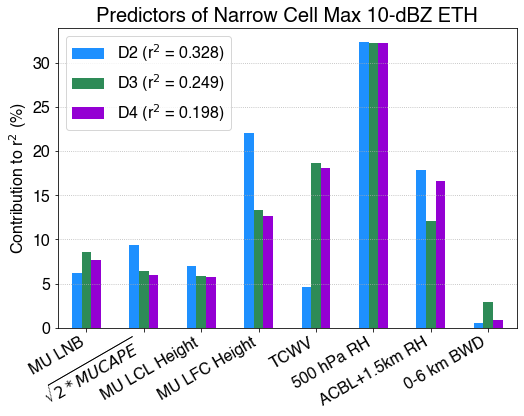

In [99]:
# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_subset_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_subset_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_subset_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"D2 (r$^2$ = {lm_narrow_std_subset_eth_d2['r2'][0]})": relimp_perc_d2,
                   f"D3 (r$^2$ = {lm_narrow_std_subset_eth_d3['r2'][0]})": relimp_perc_d3,
                   f"D4 (r$^2$ = {lm_narrow_std_subset_eth_d4['r2'][0]})": relimp_perc_d4,}, index=predictors_subset)

fig, ax = plt.subplots(1,1, figsize=(7.5,6))
color_dict = {f"D2 (r$^2$ = {lm_narrow_std_subset_eth_d2['r2'][0]})": 'dodgerblue', 
              f"D3 (r$^2$ = {lm_narrow_std_subset_eth_d3['r2'][0]})": 'seagreen',
              f"D4 (r$^2$ = {lm_narrow_std_subset_eth_d4['r2'][0]})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_Subset_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

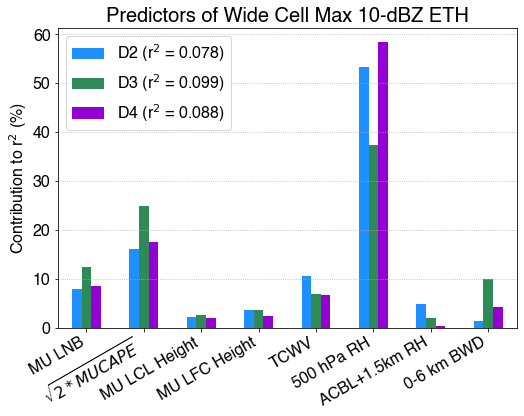

In [100]:
# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_subset_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_subset_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_subset_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

# index = ['MU LNB', '$\sqrt{2*MUCAPE}$', 'MU LCL Height', '500 hPa RH', '0-6 km BWD']
df = pd.DataFrame({f"D2 (r$^2$ = {lm_wide_std_subset_eth_d2['r2'][0]})": relimp_perc_d2,
                   f"D3 (r$^2$ = {lm_wide_std_subset_eth_d3['r2'][0]})": relimp_perc_d3,
                   f"D4 (r$^2$ = {lm_wide_std_subset_eth_d4['r2'][0]})": relimp_perc_d4,}, index=predictors_subset)

fig, ax = plt.subplots(1,1, figsize=(7.5,6))
color_dict = {f"D2 (r$^2$ = {lm_wide_std_subset_eth_d2['r2'][0]})": 'dodgerblue', 
              f"D3 (r$^2$ = {lm_wide_std_subset_eth_d3['r2'][0]})": 'seagreen',
              f"D4 (r$^2$ = {lm_wide_std_subset_eth_d4['r2'][0]})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_Subset_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

## Plot contributions to r<sup>2</sup> (including cell diameter)

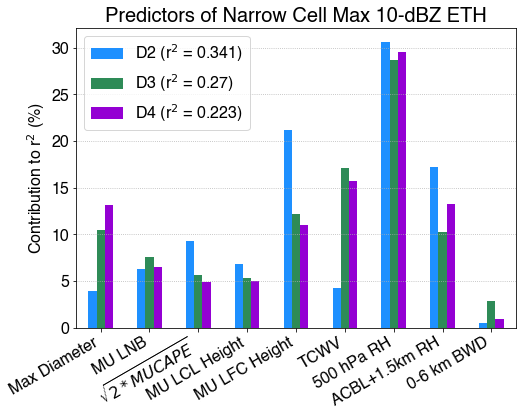

In [101]:
# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_narrow_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_narrow_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_narrow_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"D2 (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]})": relimp_perc_d2,
                   f"D3 (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]})": relimp_perc_d3,
                   f"D4 (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]})": relimp_perc_d4,}, index=predictors_all)

fig, ax = plt.subplots(1,1, figsize=(7.5,6))
color_dict = {f"D2 (r$^2$ = {lm_narrow_std_all_eth_d2['r2'][0]})": 'dodgerblue', 
              f"D3 (r$^2$ = {lm_narrow_std_all_eth_d3['r2'][0]})": 'seagreen',
              f"D4 (r$^2$ = {lm_narrow_std_all_eth_d4['r2'][0]})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Narrow Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Narrow_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

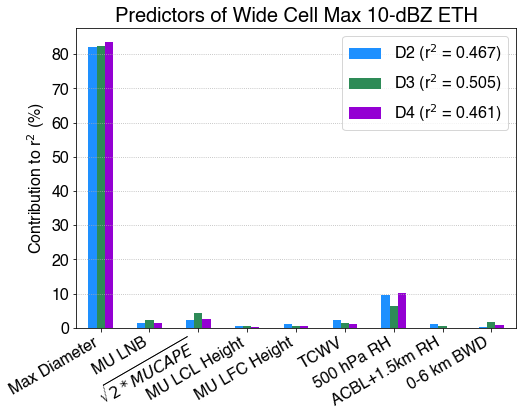

In [102]:
# Plot contributions to r**2 with r**2 values
relimp_perc_d2 = lm_wide_std_all_eth_d2[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d3 = lm_wide_std_all_eth_d3[['relimp_perc']].to_numpy()[1:].squeeze()
relimp_perc_d4 = lm_wide_std_all_eth_d4[['relimp_perc']].to_numpy()[1:].squeeze()

df = pd.DataFrame({f"D2 (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]})": relimp_perc_d2,
                   f"D3 (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]})": relimp_perc_d3,
                   f"D4 (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]})": relimp_perc_d4,}, index=predictors_all)

fig, ax = plt.subplots(1,1, figsize=(7.5,6))
color_dict = {f"D2 (r$^2$ = {lm_wide_std_all_eth_d2['r2'][0]})": 'dodgerblue', 
              f"D3 (r$^2$ = {lm_wide_std_all_eth_d3['r2'][0]})": 'seagreen',
              f"D4 (r$^2$ = {lm_wide_std_all_eth_d4['r2'][0]})": 'darkviolet'}
df.plot.bar(ax=ax, rot=30, fontsize=16, color=color_dict)
ax.legend(fontsize=16)
ax.set_ylabel('Contribution to r$^2$ (%)', fontsize=16)
ax.set_title('Predictors of Wide Cell Max 10-dBZ ETH', fontsize=20)
# ax.set_ylim(0,60)
plt.xticks(horizontalalignment='right')
ax.grid(axis='y', ls=':')

fig.tight_layout()
figname = f'{figdir}Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'
fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')

In [103]:
figname

'/gpfs/wolf2/arm/atm131/proj-shared/zfeng/cacti/les/figures/Wide_Cell_All_Predictor_Contributions_Max10dBZETH_d2_d3_d4.png'

## Function to plot nrow x ncol of histogram

In [104]:
# def plot_mxn_hist(nrow, ncol, da, hist_bins, xlabels=None, ylabels=None, titles=None, fontsize=None, figsize=None, figname=None):

#     mpl.rcParams['font.size'] = fontsize
#     mpl.rcParams['font.family'] = 'Helvetica'
    
#     fig, axes = plt.subplots(nrow, ncol, figsize=figsize, dpi=100)
#     lcolors = {'d2':'dodgerblue', 'd3':'seagreen', 'd4':'darkviolet'}
#     name_map = {'d2':'2.5 km', 'd3':'500 m', 'd4':'100 m'}
#     bar_labels = list(name_map.values())
#     bar_colors = list(lcolors.values())
    
#     for row in range(nrow):
#         for col in range(ncol):
#             ax = axes[row][col]
#             bar_data = da[row][col]
#             bins = hist_bins[row][col]
#             ax.hist(bar_data, bins=bins, alpha=1, label=bar_labels, histtype='bar', color=bar_colors, density=True)
#             for src in range(len(bar_data)):
#                 ax.axvline(np.nanmedian(bar_data[src]), color=bar_colors[src], ls='--')
#             ax.legend()
#             # ax.set_xlim(xlims[row][col])
#             ax.set_xlabel(xlabels[row][col])
#             ax.set_ylabel(ylabels[row][col])
#             ax.set_title(titles[row][col], loc='left')
#             ax.grid(ls=':')
            
#     fig.tight_layout()
#     fig.savefig(figname, bbox_inches='tight', dpi=300, facecolor='w')
#     return fig